# TESS deblending на реальных данных с `eleanor`

## Как пользоваться этим notebook

Этот notebook написан как **пошаговый учебный guide по deblending TESS**. Его цель — не просто показать несколько графиков, а постепенно ответить на вопросы:

1. почему вообще возникает blending;
2. что именно измеряет TESS;
3. как из TPF получается light curve;
4. почему выбор aperture влияет на результат;
5. как найти потенциальных contaminators по TIC/Gaia;
6. почему наличие соседа ещё не означает, что именно он создал сигнал;
7. как с помощью difference imaging проверить, **где произошло изменение потока**;
8. как использовать centroid как дополнительную spatial-проверку;
9. когда простых методов уже недостаточно.

Поэтому для каждой техники мы придерживаемся одной схемы:

**что измеряем → как это работает → что показывает → чем полезно → какие есть ограничения.**

---

## 1. Что такое blending?

TESS наблюдает не отдельные звёзды, а свет, распределённый по pixels. Размер одного пикселя TESS составляет около 21″, поэтому несколько физических источников могут давать поток в одну и ту же область изображения и попадать в одну aperture.

Это и есть **blending (блендинг)**.

Если target и соседи дают потоки `F_target(t)` и `F_i(t)`, то суммарно измеряемый поток можно схематически записать:

$$
F_{obs}(t) = F_{target}(t) + \sum_i F_i(t).
$$

### Почему blending опасен для поиска транзитов?

Рассмотрим два случая.

**Случай 1. Сосед постоянный.**

Он добавляет постоянный свет. Тогда реальное изменение target выглядит менее глубоким — возникает **dilution**.

**Случай 2. Сосед сам переменный.**

Тогда изменение соседа непосредственно попадает в нашу light curve. Мы можем увидеть transit-like или eclipse-like сигнал, который принадлежит не target.

Поэтому deblending — это не только вопрос «сколько лишнего света попало в aperture». Нам также нужно понимать:

> **какой источник действительно меняется?**

---

## 2. Почему для демонстрации выбран TIC 244279814?

TIC 244279814 — хороший учебный пример, потому что в одной TESS light curve наблюдаются два набора затмений с периодами примерно 8.42 и 9.12 суток.

Схематически наблюдаемую кривую можно представить как:

$$
F_{obs}(t) = F_A(t) + F_B(t) + F_{other}(t).
$$

Это позволяет на одном реальном объекте показать сразу две связанные, но разные проблемы:

- **суперпозицию нескольких астрофизических сигналов**;
- **blending с другими источниками в поле**.

Важно: наличие двух наборов затмений само по себе не доказывает внешнюю гравитационную связанность двух двойных. Для нашего учебного примера важно именно то, что несколько сигналов присутствуют в одной unresolved TESS light curve.

---

## 3. Общая логика notebook

Мы будем двигаться от самого простого к более сложному:

**TPF → aperture photometry → размер aperture → light curve → TIC/Gaia screening → variable neighbors → difference imaging → centroid → дополнительные реальные примеры.**

При этом WCS-to-TPF mapping **не используется для размещения target на картинках**. В текущем notebook мы используем координаты `eleanor.tpf_star_x/y`, то есть координаты target, которые `eleanor` использует внутри TPF.

Причина отказа от WCS здесь практическая: в используемом наборе данных есть неоднозначность в соглашениях о том, какая координата массива соответствует `x`, а какая `y`. Поэтому мы не хотим строить учебную демонстрацию на потенциально перепутанном преобразовании.



## 0. Импорты и настройки


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eleanor

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("eleanor version:", getattr(eleanor, "__version__", "unknown"))

from matplotlib.colors import LogNorm


d:\venvs\tess-eleanor\lib\site-packages\lightkurve\config\__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to C:\Users\tatbo\.lightkurve\cache. Please move all the files in the legacy directory C:\Users\tatbo\.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


eleanor version: 2.0.5


# 1. Основной пример: TIC 244279814, Sector 32

### Почему именно этот объект?

Для демонстрации deblending нам нужен объект, на котором одновременно видны временная структура сигнала и необходимость пространственной диагностики.

Для TIC 244279814 в опубликованном каталоге кандидатов в иерархические 2+2 системы в одной TESS light curve наблюдаются два набора затмений с периодами примерно:

- binary A: $P_A \approx 8.42$ суток;
- binary B: $P_B \approx 9.12$ суток.

В опубликованном каталоге объект рассматривается как кандидат на иерархическую 2+2 четверную систему. При этом из одной TESS light curve нельзя автоматически заключить, что две двойные гравитационно связаны внешней орбитой.

Для нашего анализа существенно другое: наблюдаемая кривая является суперпозицией нескольких сигналов:

$$
F_{obs}(t) = F_A(t) + F_B(t) + F_{other}(t).
$$

Поэтому этот объект позволяет начать с физического вопроса:

> **Что именно создаёт наблюдаемую переменность и где находится источник этого изменения?**

Дальше мы последовательно переходим от временной light curve к пространственной информации TPF.

**Источник для описания объекта:** Kostov et al., *101 eclipsing quadruple star candidates discovered in TESS full frame images*.


In [2]:
tic = 244279814
sector = 32

star = eleanor.Source(tic=tic, sector=sector, tc=True)

print("TIC:", star.tic)
print("Gaia:", getattr(star, "gaia", None))
print("Sector:", star.sector)
print("Tmag:", star.tess_mag)
print("RA, Dec:", star.coords)


TIC: 244279814
Gaia: 3225574628900364800
Sector: 32
Tmag: 13.3041
RA, Dec: [74.7625019767822, -2.11103856804875]


## 1.1 Загружаем TPF

Здесь не используем PSF и PCA. 

Обратите внимание на важную особенность `eleanor`: при работе через `TessCut` TPF специально вырезается вокруг координат target. 

In [3]:
data = eleanor.TargetData(
    star,
    do_psf=False,
    do_pca=False,
    aperture_mode="normal"
)

print("TPF shape:", np.asarray(data.tpf).shape)
print("Chosen aperture shape:", np.asarray(data.aperture).shape)
print("best_ind:", getattr(data, "best_ind", None))
print("tpf_star_x, tpf_star_y:", getattr(data, "tpf_star_x", None), getattr(data, "tpf_star_y", None))


TPF shape: (3600, 13, 13)
Chosen aperture shape: (13, 13)
best_ind: 4
tpf_star_x, tpf_star_y: 6 6


# 2. TPF и median TPF: где вообще находится свет?

Target Pixel File можно рассматривать как трёхмерный массив:

$$
TPF(t,y,x),
$$

где $t$ — время, а $(x,y)$ — положение пикселя.

Для устойчивой визуализации поля можно взять медиану по времени:

$$
I_{median}(y,x) = median_t\left[TPF(t,y,x)\right].
$$

Это уже не light curve, а **пространственная картина потока**.


В следующих ячейках мы используем TPF как основной источник spatial information.


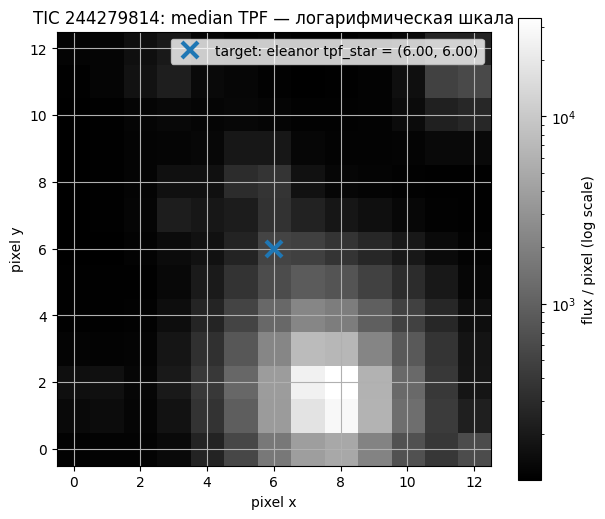

TPF shape: (13, 13)
Target coordinates used: 6 6


In [4]:
# Median TPF: spatial-картина потока.
frame_median = np.nanmedian(np.asarray(data.tpf), axis=0)

# Определяем координаты target ДО визуализации.
# Это исправляет ошибку NameError при запуске ячейки на чистом ядре.
target_x_demo = getattr(data, "tpf_star_x", None)
target_y_demo = getattr(data, "tpf_star_y", None)

from matplotlib.colors import LogNorm

def positive_log_norm(image, low=1.0, high=99.8):
    values = np.asarray(image, dtype=float)
    positive = values[np.isfinite(values) & (values > 0)]
    if positive.size == 0:
        raise ValueError("В изображении нет положительных значений для LogNorm.")
    vmin = np.nanpercentile(positive, low)
    vmax = np.nanpercentile(positive, high)
    if vmin <= 0:
        vmin = np.nanmin(positive)
    if vmax <= vmin:
        vmax = vmin * 10.0
    return LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(frame_median, origin="lower", cmap="gray",
               norm=positive_log_norm(frame_median))
plt.colorbar(im, ax=ax, label="flux / pixel (log scale)")

if target_x_demo is not None and target_y_demo is not None:
    ax.plot(target_x_demo, target_y_demo, "x", ms=12, mew=3,
            label=f"target: eleanor tpf_star = ({target_x_demo:.2f}, {target_y_demo:.2f})")

ax.set_title("TIC 244279814: median TPF — логарифмическая шкала")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.legend()
plt.show()

print("TPF shape:", frame_median.shape)
print("Target coordinates used:", target_x_demo, target_y_demo)


## 2.1. Где находится target внутри TPF?

Здесь важно различать **рабочую координату `eleanor`** и **астрометрическую координату из WCS**.

`data.tpf_star_x` и `data.tpf_star_y` — координаты target, которые `eleanor` предоставляет внутри TPF. Они удобны для photometry.

Но для проверки положения **каталоговых источников** нужен WCS. Для этого нужно сделать специальное преобразование.


In [5]:
from astropy.wcs import WCS

# Точная схема преобразования, использованная в gaia_overlay.py / wcs_gaia.txt.
wcs = WCS(star.cutout[2].header)

cutout_shape = np.asarray(star.cutout[2].data).shape
tpf_shape = np.asarray(data.tpf).shape[-2:]

offset_y = (cutout_shape[0] - tpf_shape[0]) // 2
offset_x = (cutout_shape[1] - tpf_shape[1]) // 2

def world_to_tpf(ra, dec):
    """RA/Dec -> координаты NumPy TPF: (row, col)."""
    x_wcs, y_wcs = wcs.all_world2pix([[ra, dec]], 0)[0]
    row = y_wcs - offset_y
    col = x_wcs - offset_x
    return float(row), float(col)

target_row_wcs, target_col_wcs = world_to_tpf(
    float(star.coords[0]), float(star.coords[1])
)

print(f"Target from eleanor: x={target_x_demo:.3f}, y={target_y_demo:.3f}")
print(f"Target from WCS: row={target_row_wcs:.3f}, col={target_col_wcs:.3f}")
print(f"Difference: Δrow={target_row_wcs-target_y_demo:.3f}, "
      f"Δcol={target_col_wcs-target_x_demo:.3f} pixel")
print("TPF shape:", tpf_shape, "cutout shape:", cutout_shape)


Target from eleanor: x=6.000, y=6.000
Target from WCS: row=6.195, col=6.204
Difference: Δrow=0.195, Δcol=0.204 pixel
TPF shape: (13, 13) cutout shape: (31, 31)


## 2.2. Что мы видим на median TPF?

Median TPF показывает, **где в вырезке находится зарегистрированный поток**, но сама по себе не говорит, какой источник переменный.

### Что можно заключить?

Можно увидеть spatial structure, положение target, соседние источники и overlap с aperture. Но это ещё не доказательство, **кто создал конкретный минимум**. Для этого нужна временная информация и difference imaging.


## 2.3. Custom aperture: что это такое?

Aperture — это набор пикселей, которые мы складываем в одну light curve:

$$
F_{ap}(t)=\sum_{p\in A}F_p(t).
$$

Aperture не знает, какой физической звезде принадлежит пиксель. Поэтому внутри одной aperture могут оказаться часть света target, свет соседей и background.

### Где здесь появляется PSF?

Звезда не является одной точкой в TPF: её свет размазан по нескольким pixels. Это spatial footprint, связанный с PSF/PRF.

Если мы просто складываем pixels, нам не нужно явно моделировать PSF. Но если хотим оценить, **какая доля света конкретной звезды попала в aperture**, нужна spatial model.

В отдельной каталожной демонстрации `gaia_overlay.py` это сделано упрощённо: для каждого Gaia source вычисляется Gaussian-PSF weight `aperture_fraction(...)`, параметризованный `PSF_SIGMA_PX`; затем weight умножается на поток, оценённый из magnitude.

Это полезная демонстрация идеи, но это **не полноценный TESS PRF deblending**.

### PSF и PRF простыми словами

**PSF:** как выглядит пятно одной точечной звезды.

**PRF:** как это пятно реально распределяется по дискретным pixels TESS.

**Aperture:** какие pixels мы решили сложить.

Поэтому точное `α_i` — долю света источника в aperture — нельзя получить только из расстояния и magnitude.


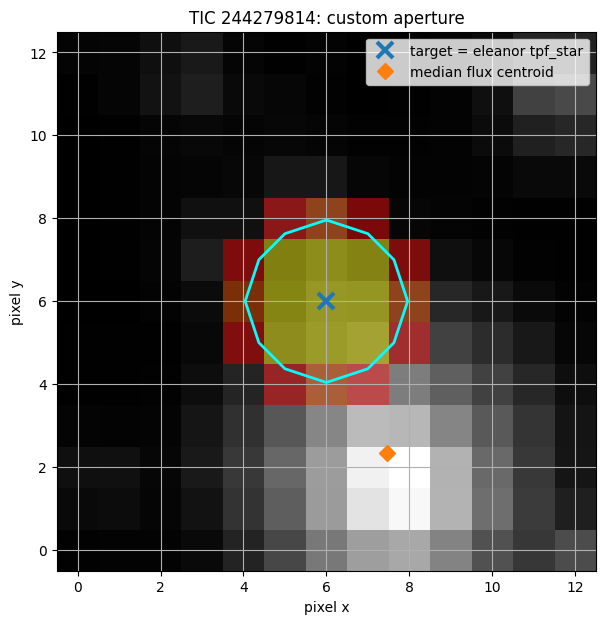

In [6]:
# Custom aperture с центром в координате target, которую использует eleanor.
custom = eleanor.TargetData(
    star,
    do_psf=False,
    do_pca=False,
    aperture_mode="normal"
)

custom.custom_aperture(
    shape="circle",
    r=2.0,
    pos=(target_x_demo, target_y_demo),
    method="exact"
)
custom.get_lightcurve(aperture=custom.aperture)

custom_ap = np.asarray(custom.aperture)

# Центр тяжести median TPF — нужен только для визуального сравнения.
# Здесь он вычисляется напрямую из median TPF, поэтому не зависит от
# отдельной ячейки/переменной с предыдущих запусков.
centroid_flux = np.clip(np.asarray(frame_median, dtype=float), 0, None)
y_idx, x_idx = np.indices(centroid_flux.shape)
centroid_sum = np.nansum(centroid_flux)
if centroid_sum > 0:
    xcom_med = np.nansum(x_idx * centroid_flux) / centroid_sum
    ycom_med = np.nansum(y_idx * centroid_flux) / centroid_sum
else:
    xcom_med, ycom_med = np.nan, np.nan

fig, ax = plt.subplots(figsize=(8, 7))

# TPF показываем в log scale.
ax.imshow(
    frame_median,
    origin="lower",
    cmap="gray",
    norm=positive_log_norm(frame_median)
)

ax.imshow(
    np.ma.masked_where(custom_ap <= 0, custom_ap),
    origin="lower",
    cmap="autumn",
    alpha=0.45
)
ax.contour(custom_ap, levels=[0.5], colors="cyan", linewidths=2)

ax.plot(
    target_x_demo, target_y_demo,
    "x", ms=12, mew=3,
    label="target = eleanor tpf_star"
)
ax.plot(
    xcom_med, ycom_med,
    "D", ms=8,
    label="median flux centroid"
)

ax.set_title("TIC 244279814: custom aperture")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.legend()
plt.show()


# 3. Aperture photometry

Самый простой способ получить light curve из TPF — выбрать набор пикселей $A$ и сложить их поток:

$$
F_{ap}(t) = \sum_{p \in A} F_p(t).
$$

Проблема состоит в том, что aperture не знает, какому физическому источнику принадлежит каждый пиксель.

Поэтому размер и положение aperture влияют одновременно на:

- долю собственного потока target;
- вклад соседних источников;
- background;
- чувствительность к дрейфу изображения;
- S/N.

То есть выбор aperture — уже часть задачи deblending.

**Aperture photometry не является полноценным разделением источников:** мы просто определяем, какие pixels войдут в одну суммарную light curve.

Следующим шагом мы проведём контролируемый эксперимент с несколькими радиусами при одном и том же центре.


## 3.1. Почему нужно отдельно проверять размер aperture?

Теперь фиксируем **один и тот же target position**, а размер aperture меняем.

Это важный учебный эксперимент: если меняется только радиус, мы можем увидеть влияние именно размера aperture.

Есть два противоположных эффекта.

### Маленькая aperture

Плюсы:

- меньше соседнего света;
- потенциально меньше contamination.

Минусы:

- часть собственного света target может быть потеряна;
- photometry может стать чувствительнее к движению изображения;
- S/N может ухудшиться.

### Большая aperture

Плюсы:

- больше собственного flux target;
- меньше риск потерять часть PRF/PSF.

Минусы:

- в aperture попадает больше соседнего света;
- возрастает риск dilution;
- переменный сосед может внести дополнительный сигнал.

Поэтому нет универсального правила «чем меньше aperture, тем лучше».


Важно: режимы `normal`, `small`, `large`, `all` в `eleanor` — это алгоритмические варианты aperture и не являются тем же самым экспериментом, что наши фиксированные круговые apertures.


In [7]:
# Контролируемый эксперимент:
# один и тот же target position, меняется только радиус aperture.
custom_radii = [1.0, 2.0, 3.0, 4.0]
custom_aperture_results = {}

for r in custom_radii:
    d = eleanor.TargetData(
        star, do_psf=False, do_pca=False, aperture_mode="normal"
    )
    d.custom_aperture(
        shape="circle",
        r=r,
        pos=(target_x_demo, target_y_demo),
        method="exact"
    )
    d.get_lightcurve(aperture=d.aperture)

    q = np.asarray(d.quality) == 0
    t = np.asarray(d.time)[q]
    f = np.asarray(d.corr_flux)[q].astype(float)
    f = f / np.nanmedian(f)

    custom_aperture_results[r] = (d, t, f)

    print(
        f"radius={r:.1f} px: selected pixels={np.sum(np.asarray(d.aperture) > 0):3d}"
    )


radius=1.0 px: selected pixels=  9
radius=2.0 px: selected pixels= 21
radius=3.0 px: selected pixels= 45
radius=4.0 px: selected pixels= 69


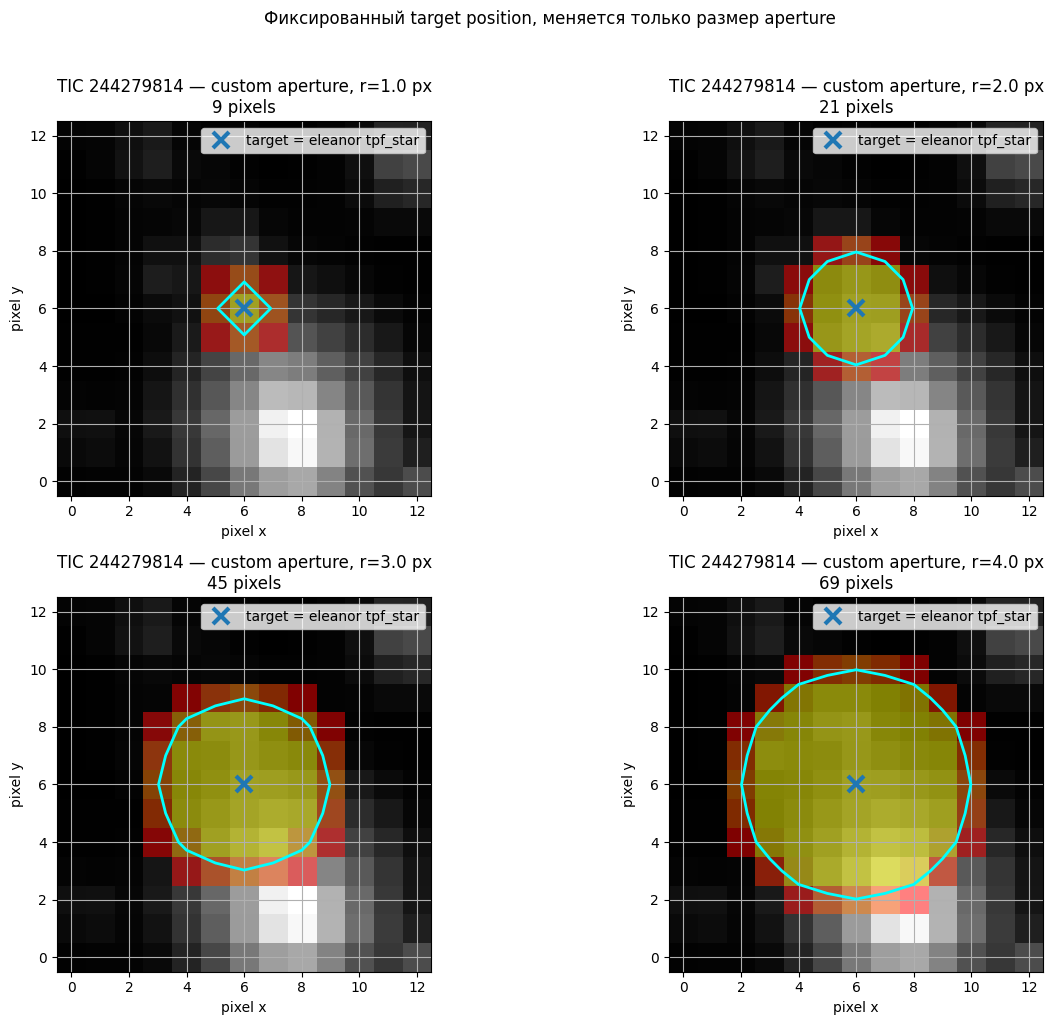

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, r in zip(axes.ravel(), custom_radii):
    d, _, _ = custom_aperture_results[r]
    ap = np.asarray(d.aperture)

    ax.imshow(
        frame_median,
        origin="lower",
        cmap="gray",
        norm=positive_log_norm(frame_median)
    )
    ax.imshow(
        np.ma.masked_where(ap <= 0, ap),
        origin="lower",
        cmap="autumn",
        alpha=0.50
    )
    ax.contour(ap, levels=[0.5], colors="cyan", linewidths=2)

    ax.plot(
        target_x_demo, target_y_demo,
        "x", ms=11, mew=3,
        label="target = eleanor tpf_star"
    )

    ax.set_title(
        f"TIC 244279814 — custom aperture, r={r:.1f} px\n"
        f"{int(np.sum(ap > 0))} pixels"
    )
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    ax.legend(loc="upper right")

plt.suptitle(
    "Фиксированный target position, меняется только размер aperture",
    y=1.02
)
plt.tight_layout()
plt.show()


## 3.2. Что показывает этот эксперимент?

Здесь важно не смотреть только на форму aperture.

Нас интересуют три вещи:

1. **сколько пикселей мы включили;**
2. **сколько собственного света target мы потенциально собираем;**
3. **сколько дополнительного поля включаем вместе с ним.**



# 4. Что происходит физически в TIC 244279814?

Теперь связываем пространственный анализ с временной light curve.

Для одного eclipsing binary во время затмения часть излучения системы закрывается, поэтому суммарный flux уменьшается. Если в наблюдаемом объекте присутствуют два набора затмений, измеряемый поток можно схематически записать как:

$$
F_{obs}(t) = F_A(t) + F_B(t) + F_{other}(t).
$$

Поэтому два набора провалов в одной light curve не обязательно означают ошибку обработки: они могут быть физической суперпозицией двух периодических сигналов.

Здесь важно отделить две вещи:

1. **суперпозиция астрофизических сигналов внутри одного unresolved target**;
2. **blending с другими источниками на небе**.

Дальше notebook показывает именно вторую проблему: какие внешние источники могут попадать в aperture и как проверить, не они ли создают наблюдаемое событие.


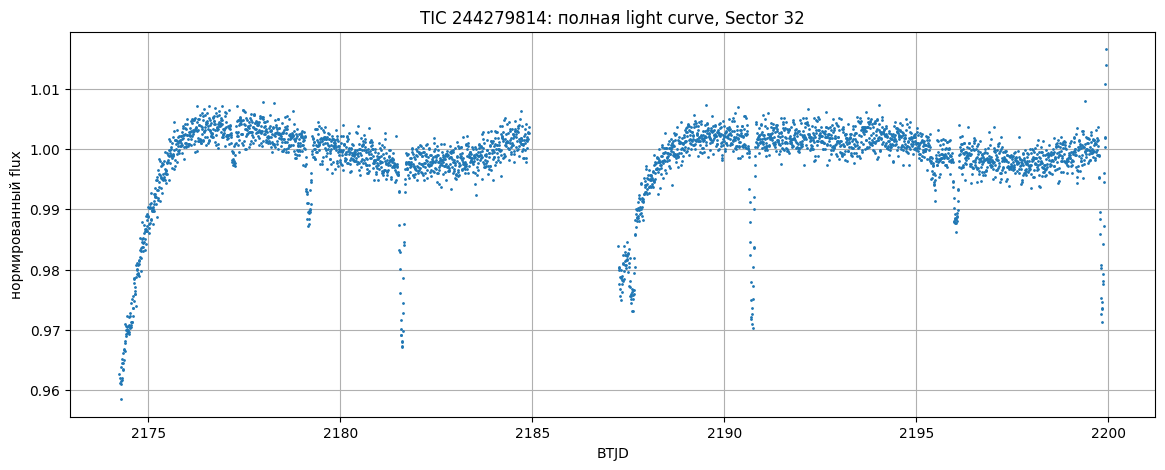

In [9]:
q = np.asarray(data.quality) == 0
time = np.asarray(data.time)[q]
flux = np.asarray(data.corr_flux)[q].astype(float)
norm_flux = flux / np.nanmedian(flux)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time, norm_flux, ".", ms=2)
ax.set_xlabel("BTJD")
ax.set_ylabel("нормированный flux")
ax.set_title("TIC 244279814: полная light curve, Sector 32")
plt.show()


# 5. PCA / временные систематики — отдельная задача

PCA/cotrending отвечает на вопрос о **временных систематиках**, а не о spatial blending.

Идея:

$$
F(t)=S(t)+\sum_k a_kB_k(t),
$$

где `S(t)` — астрофизический сигнал, а `B_k(t)` — общие временные шаблоны систематики.

### Почему после PCA может появиться сильный наклон?

Это **не обязательно инструментальный шум и не обязательно физический тренд**.

PCA вычитает линейную комбинацию cotrending vectors. Если среди них есть плавно меняющийся шаблон, результат может заметно изменить наклон light curve.

Сильный наклон после PCA может означать:

- остаточную систематику, которую PCA не описал;
- изменение фона/photometric response;
- реальную астрофизическую вариабельность;
- результат слишком гибкого detrending.

Поэтому по одному графику после PCA нельзя говорить «это инструментальный шум».

### Как проверять?

1. Сравнить raw, `corr_flux` и PCA-output.
2. Посмотреть другие источники того же сектора.
3. Проверить начало и конец сектора отдельно.
4. Сравнить 0, 3 и 10 cotrending vectors.
5. Не использовать PCA как доказательство spatial происхождения сигнала.

**Вывод:** PCA — detrending, а не deblending.


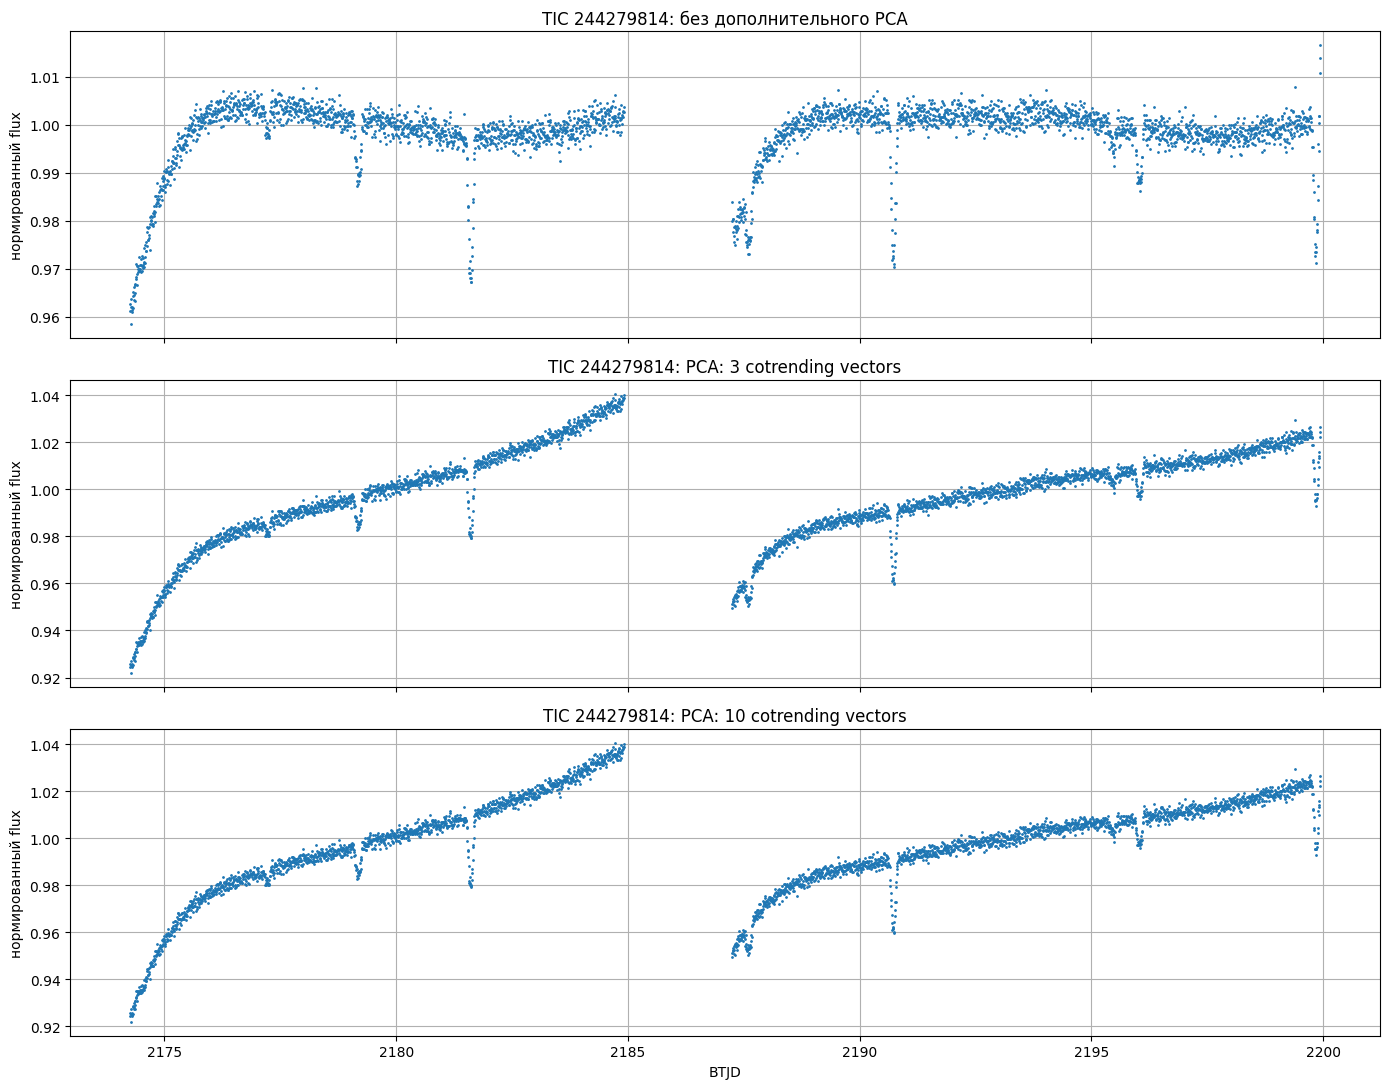

In [10]:
pca_results = {}

base = eleanor.TargetData(
    star,
    do_psf=False,
    do_pca=False,
    aperture_mode="normal"
)

q = np.asarray(base.quality) == 0
t_all = np.asarray(base.time).astype(float)
raw = np.asarray(base.raw_flux).astype(float)
corr = np.asarray(base.corr_flux).astype(float)

for modes in [0, 3, 10]:
    if modes == 0:
        out = corr.copy()
        label = "без дополнительного PCA"
    else:
        # В eleanor corrected_flux(..., pca=True) сохраняет результат
        # в base.pca_flux и не возвращает массив.
        base.corrected_flux(
            flux=raw,
            modes=modes,
            pca=True
        )
        out = np.asarray(base.pca_flux, dtype=float).copy()
        label = f"PCA: {modes} cotrending vectors"

    if out.ndim != 1 or len(out) != len(t_all):
        raise ValueError(
            f"PCA output имеет форму {out.shape}, ожидалась ({len(t_all)},)."
        )

    q_now = q & np.isfinite(out) & np.isfinite(t_all)
    tt = t_all[q_now]
    ff = out[q_now]
    ff = ff / np.nanmedian(ff)

    pca_results[modes] = (tt, ff, label)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

for ax, modes in zip(axes, [0, 3, 10]):
    tt, ff, label = pca_results[modes]
    ax.plot(tt, ff, ".", ms=2)
    ax.set_ylabel("нормированный flux")
    ax.set_title(f"TIC 244279814: {label}")

axes[-1].set_xlabel("BTJD")
plt.tight_layout()
plt.show()


## 5.1. Как читать PCA = 0 / 3 / 10?

PCA **не «вычитает соседнюю звезду»**. Он работает с временной зависимостью flux.

- **0** — дополнительное PCA не применяется;
- **3** — разрешено использовать три cotrending vectors;
- **10** — модель гибче и может убрать больше временной структуры.

Чем больше vectors, тем больше свободы. Это помогает убрать сложную систематику, но повышает риск удалить слабый astrophysical signal.

### Почему нельзя автоматически считать сильный наклон после PCA шумом?

Потому что наклон может быть остаточной инструментальной систематикой, изменением фона/апертуры, реальной вариабельностью или следствием detrending.

Нужен контроль по raw/corrected curves и по другим источникам сектора.

Для ML-пайплайна важно сохранять исходную/менее обработанную кривую и параметры detrending.


# 6. Dilution: откуда практически берётся c?

Пусть в aperture попал поток target `F_t` и постоянный поток соседей `F_cont`.

Если вне события поток target нормирован к 1:

$$
F_{obs}(t)=cF_{target}(t)+(1-c),
$$

где

$$
c=\frac{F_{target,ap}}
        {F_{target,ap}+F_{cont}}.
$$

То есть **`c` — доля света target среди всего постоянного света, реально попавшего в photometry**.

### Как получить c практически?

Для каждого источника нужны:

1. его полный поток `F_i`;
2. доля этого потока, попавшая в aperture, `α_i`.

Тогда:

$$
F_{target,ap}=\alpha_tF_t,
$$

$$
F_{cont}=\sum_i\alpha_iF_i,
$$

и

$$
c=\frac{\alpha_tF_t}
        {\alpha_tF_t+\sum_i\alpha_iF_i}.
$$

Отношение полных потоков можно получить из magnitude:

$$
\frac{F_i}{F_t}=10^{-0.4(m_i-m_t)}.
$$

Но magnitude **не достаточно**: нужна ещё `α_i`, spatial throughput.


### Ограничение

Если `α_i` получена из упрощённой Gaussian PSF, то `C` и `c` — **модельные оценки**, а не точное измерение истинного flux decomposition.


In [11]:
def read_crowding_metrics(obj):
    """Try to find SPOC-style crowding metrics in available headers."""
    headers = []
    for candidate in [
        getattr(obj, "header", None),
        getattr(getattr(obj, "post_obj", None), "header", None),
    ]:
        if candidate is not None:
            headers.append(candidate)

    found = {}
    for h in headers:
        for key in ["CROWDSAP", "FLFRCSAP"]:
            value = h.get(key, None) if hasattr(h, "get") else None
            if value is not None:
                found[key] = value
    return found

crowding_metrics = read_crowding_metrics(data)
print("Найденные CROWDSAP/FLFRCSAP в eleanor:", crowding_metrics)

crowdsap_real = crowding_metrics.get("CROWDSAP")
flfrcsap_real = crowding_metrics.get("FLFRCSAP")

# These values are intentionally educational if eleanor does not provide
# SPOC-style keywords. They are NOT measurements of TIC 244279814.
if crowdsap_real is None or flfrcsap_real is None:
    crowdsap_demo, flfrcsap_demo = 0.80, 0.70
    print("В TargetData eleanor эти SPOC-параметры отсутствуют.")
    print(f"Для демонстрации используем условно: CROWDSAP={crowdsap_demo:.2f}, FLFRCSAP={flfrcsap_demo:.2f}.")
    print("Это учебные значения, а не измерения TIC 244279814.")
else:
    crowdsap_demo = float(crowdsap_real)
    flfrcsap_demo = float(flfrcsap_real)

# Important: we do NOT multiply the whole light curve by CROWDSAP.
# For a normalized light curve, a simple dilution model is:
# F_obs = C * F_target + (1-C)
# therefore F_target = 1 + (F_obs - 1) / C.
true_flux_demo = 1.0 - 0.04
observed_flux_demo = 1.0 - 0.04 * crowdsap_demo
recovered_flux_demo = 1.0 + (observed_flux_demo - 1.0) / crowdsap_demo

print(f"Учебный CROWDSAP: {crowdsap_demo:.3f}")
print(f"Учебный FLFRCSAP: {flfrcsap_demo:.3f}")
print(f"Истинный normalized flux при eclipse 4%: {true_flux_demo:.3f}")
print(f"Наблюдаемый flux после dilution: {observed_flux_demo:.3f}")
print(f"Простая коррекция dilution: {recovered_flux_demo:.3f}")
print("FLFRCSAP здесь не используется для изменения нормированной глубины: потеря общего target flux меняет масштаб, но не сама по себе относительную глубину.")



Найденные CROWDSAP/FLFRCSAP в eleanor: {}
В TargetData eleanor эти SPOC-параметры отсутствуют.
Для демонстрации используем условно: CROWDSAP=0.80, FLFRCSAP=0.70.
Это учебные значения, а не измерения TIC 244279814.
Учебный CROWDSAP: 0.800
Учебный FLFRCSAP: 0.700
Истинный normalized flux при eclipse 4%: 0.960
Наблюдаемый flux после dilution: 0.968
Простая коррекция dilution: 0.960
FLFRCSAP здесь не используется для изменения нормированной глубины: потеря общего target flux меняет масштаб, но не сама по себе относительную глубину.


# 7. TIC и Gaia: сначала ищем потенциальных contaminators

Каталоги отвечают на вопрос:

> **Какие источники вообще находятся рядом с target?**

Но для deblending нам нужны не все соседи подряд.

### Практический screening

Кандидат становится интересным, если выполняется хотя бы одно из условий:

1. он достаточно близок;
2. он достаточно яркий относительно target;
3. его WCS-положение попадает в TPF/aperture;
4. он известен как переменный;
5. его изменение совпадает по времени с событием.

Число `60″` ниже — **учебный screening threshold**, а не физическая граница TESS blending.

Для Gaia важно также учитывать proper motion: Gaia DR3 координаты относятся к reference epoch 2016.0, а TESS наблюдал объект позднее. Поэтому для точного overlay координаты Gaia нужно перенести на эпоху наблюдения, если `pmra/pmdec` доступны.


In [12]:
# MAST/TIC cone search
from astropy.coordinates import SkyCoord
import astropy.units as u

target_coord = SkyCoord(
    ra=float(star.coords[0]) * u.deg,
    dec=float(star.coords[1]) * u.deg
)

try:
    from astroquery.mast import Catalogs

    tic_neighbors = Catalogs.query_region(
        target_coord,
        radius=223 * u.arcsec,
        catalog="Tic"
    )

    tic_df = tic_neighbors.to_pandas()
    wanted = [c for c in ["ID", "ra", "dec", "Tmag"] if c in tic_df.columns]
    tic_df = tic_df[wanted].copy()
    tic_df = tic_df.sort_values("Tmag")

    display(tic_df.head(20))
except Exception as e:
    print("TIC query не выполнился:", repr(e))
    tic_df = None


,ID,ra,dec,Tmag
26,244279829,74.774369,-2.136633,7.42618
80,213033891,74.800856,-2.146426,11.87560
54,244279797,74.790163,-2.079904,12.34150
3,244279809,74.757630,-2.101091,13.15080
0,244279814,74.762502,-2.111039,13.30410
98,244279784,74.745881,-2.051490,13.35880
19,244279826,74.769928,-2.133828,13.73180
10,244279813,74.745084,-2.108390,14.16440
46,244279800,74.738898,-2.083733,14.45900
53,244279835,74.734451,-2.141731,15.06830


In [15]:
# Gaia DR3 cone search.
# ВАЖНО: radius передаём keyword argument.
# В новых версиях astroquery:
# Gaia.cone_search_async(coordinate, *, radius=...)
#
try:
    from astroquery.gaia import Gaia

    radius = 223 * u.arcsec
    gaia_job = Gaia.cone_search_async(
        target_coord,
        radius=radius
    )
    gaia_table = gaia_job.get_results()
    gaia_df = gaia_table.to_pandas()

    wanted = [
        c for c in [
            "source_id", "ra", "dec", "phot_g_mean_mag",
            "phot_bp_mean_mag", "phot_rp_mean_mag",
            "parallax", "pmra", "pmdec", "ruwe", "ref_epoch"
        ]
        if c in gaia_df.columns
    ]
    gaia_df = gaia_df[wanted].sort_values("phot_g_mean_mag")

    display(gaia_df.head(20))
except Exception as e:
    print("Gaia query не выполнился:", repr(e))
    gaia_df = None


INFO: Query finished. [astroquery.utils.tap.core]


,ra,dec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,parallax,pmra,pmdec,ruwe,ref_epoch
26,74.774349,-2.136590,7.498104,7.538070,7.395806,5.661963,-4.581733,10.069136,1.054135,2016.0
3,74.757599,-2.101204,13.680758,14.101598,13.082852,2.431093,-7.021336,-25.633563,1.135418,2016.0
0,74.762522,-2.111035,13.741033,14.075464,13.235859,0.912727,4.498543,0.541318,1.864852,2016.0
19,74.770022,-2.133853,14.285012,14.727794,13.659895,1.973329,21.213869,-5.697431,1.003724,2016.0
10,74.745076,-2.108372,14.652884,15.043386,14.099510,0.798656,-1.880115,4.193113,1.012765,2016.0
47,74.738893,-2.083762,14.922008,15.246918,14.376642,0.649421,-1.032976,-6.585921,1.644387,2016.0
42,74.738672,-2.085750,15.842257,16.464100,15.086813,1.710274,-3.417875,-4.372444,1.049585,2016.0
43,74.756845,-2.145354,15.916763,16.010101,15.757127,0.140456,1.251355,-0.042265,0.961471,2016.0
12,74.762153,-2.129257,16.143921,16.550117,15.575557,0.787831,0.778235,3.441843,1.021106,2016.0
27,74.786893,-2.125565,16.179913,16.545311,15.594301,3.327701,1.461353,1.057734,15.276257,2016.0


## 7.0.1. Эпоха Gaia и эпоха TESS: нужно ли пересчитывать координаты?

Да — для точного астрометрического overlay это правильная процедура.

Gaia DR3 даёт `ra`, `dec` и proper motion относительно своей reference epoch `2016.0`. TESS наблюдение имеет собственную дату. Поэтому правильная цепочка:

**Gaia position at 2016.0 → proper-motion propagation → position at TESS epoch → WCS → TPF pixel.**

Для большинства обычных звёзд за несколько лет сдвиг меньше TESS pixel (~20–21″), но для high-proper-motion sources он может стать существенным.

Важно: текущий `gaia_overlay.py` использует Gaia RA/Dec напрямую и не делает propagation. Поэтому старый overlay хорош как демонстрация WCS, но для точного каталожного анализа его нужно считать приближённым для источников с заметным proper motion. 

In [16]:
from astropy.time import Time
from astropy.coordinates import SkyCoord

tess_obstime = Time(
    2457000.0 + np.nanmedian(np.asarray(data.time, dtype=float)),
    format="jd",
    scale="tdb"
)
GAIA_EPOCH = Time(2016.0, format="jyear")

print("Gaia reference epoch:", GAIA_EPOCH.jyear)
print("TESS observation epoch:", tess_obstime.jyear)

def propagate_gaia_to_tess_epoch(df):
    df = df.copy()
    ra_out = np.full(len(df), np.nan)
    dec_out = np.full(len(df), np.nan)

    for j, (_, row) in enumerate(df.iterrows()):
        if not np.isfinite(row.get("ra", np.nan)) or not np.isfinite(row.get("dec", np.nan)):
            continue

        pmra = row.get("pmra", np.nan)
        pmdec = row.get("pmdec", np.nan)

        if np.isfinite(pmra) and np.isfinite(pmdec):
            c = SkyCoord(
                ra=float(row["ra"])*u.deg,
                dec=float(row["dec"])*u.deg,
                pm_ra_cosdec=float(pmra)*u.mas/u.yr,
                pm_dec=float(pmdec)*u.mas/u.yr,
                obstime=GAIA_EPOCH,
                frame="icrs"
            )
            c2 = c.apply_space_motion(new_obstime=tess_obstime)
            ra_out[j] = c2.ra.deg
            dec_out[j] = c2.dec.deg
        else:
            ra_out[j] = float(row["ra"])
            dec_out[j] = float(row["dec"])

    df["ra_tess_epoch"] = ra_out
    df["dec_tess_epoch"] = dec_out
    return df

if gaia_df is not None and len(gaia_df):
    gaia_epoch = propagate_gaia_to_tess_epoch(gaia_df)

    gaia_epoch["tpf_row"], gaia_epoch["tpf_col"] = zip(*[
        world_to_tpf(ra, dec)
        if np.isfinite(ra) and np.isfinite(dec)
        else (np.nan, np.nan)
        for ra, dec in zip(
            gaia_epoch["ra_tess_epoch"],
            gaia_epoch["dec_tess_epoch"]
        )
    ])

    display(
        gaia_epoch[
            [c for c in [
                "source_id","ra","dec","pmra","pmdec",
                "ra_tess_epoch","dec_tess_epoch","tpf_row","tpf_col"
            ] if c in gaia_epoch.columns]
        ].head(20)
    )

# Для target стараемся использовать ту же Gaia astrometry.
# Если ближайший Gaia source находится в пределах 1", используем его
# propagated position; иначе оставляем TIC position как fallback.
if gaia_epoch is not None and len(gaia_epoch):
    target_sky = SkyCoord(
        ra=float(star.coords[0])*u.deg,
        dec=float(star.coords[1])*u.deg
    )
    gaia_sky = SkyCoord(
        ra=gaia_epoch["ra_tess_epoch"].to_numpy()*u.deg,
        dec=gaia_epoch["dec_tess_epoch"].to_numpy()*u.deg
    )
    sep = target_sky.separation(gaia_sky)
    k = int(np.nanargmin(sep.arcsec))

    if np.isfinite(sep[k].arcsec) and sep[k].arcsec <= 1.0:
        target_ra_for_wcs = float(gaia_epoch.iloc[k]["ra_tess_epoch"])
        target_dec_for_wcs = float(gaia_epoch.iloc[k]["dec_tess_epoch"])
        target_row_wcs, target_col_wcs = world_to_tpf(
            target_ra_for_wcs, target_dec_for_wcs
        )
        print(
            f"Target WCS position uses Gaia propagated astrometry; "
            f"catalog separation from TIC = {sep[k].arcsec:.3f}."
        )
    else:
        print("Gaia target match within 1 not found; using TIC coordinates.")


Gaia reference epoch: 2016.0
TESS observation epoch: 2020.92466685373


d:\venvs\tess-eleanor\lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "pmsafe" yielded 1 of "distance overridden (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


,ra,dec,pmra,pmdec,ra_tess_epoch,dec_tess_epoch,tpf_row,tpf_col
26,74.774349,-2.136590,-4.581733,10.069136,74.774343,-2.136576,1.513582,7.668682
3,74.757599,-2.101204,-7.021336,-25.633563,74.757589,-2.101239,8.000077,5.578710
0,74.762522,-2.111035,4.498543,0.541318,74.762528,-2.111035,6.195159,6.208281
19,74.770022,-2.133853,21.213869,-5.697431,74.770051,-2.133861,2.081794,6.996085
10,74.745076,-2.108372,-1.880115,4.193113,74.745073,-2.108366,7.061339,3.291342
47,74.738893,-2.083762,-1.032976,-6.585921,74.738892,-2.083771,11.448764,2.770454
42,74.738672,-2.085750,-3.417875,-4.372444,74.738667,-2.085756,11.111502,2.689111
43,74.756845,-2.145354,1.251355,-0.042265,74.756847,-2.145354,0.405615,4.496923
12,74.762153,-2.129257,0.778235,3.441843,74.762154,-2.129252,3.060588,5.750041
27,74.786893,-2.125565,1.461353,1.057734,74.786895,-2.125563,3.121948,10.046337


Target WCS position uses Gaia propagated astrometry; catalog separation from TIC = 0.095.


## 7.1. Как читать screening plot?

Сначала смотрим sky coordinates:

- X = angular separation от target;
- Y = `ΔTmag`;
- target = `(0,0)`.

Это отвечает на вопрос «кто потенциально опасен?», но ещё не говорит, сколько его flux реально попало в aperture.

Следующий шаг — **WCS overlay**.

### Почему нельзя просто сравнить RA/Dec Gaia с TPF?

Потому что TPF живёт в pixel coordinates, а Gaia — в sky coordinates. Между ними есть WCS-преобразование, включая поворот кадра.

В `wcs_gaia.txt` показано:

`WCS(header) → all_world2pix → axis swap → offset`.

Именно эту схему теперь использует notebook.


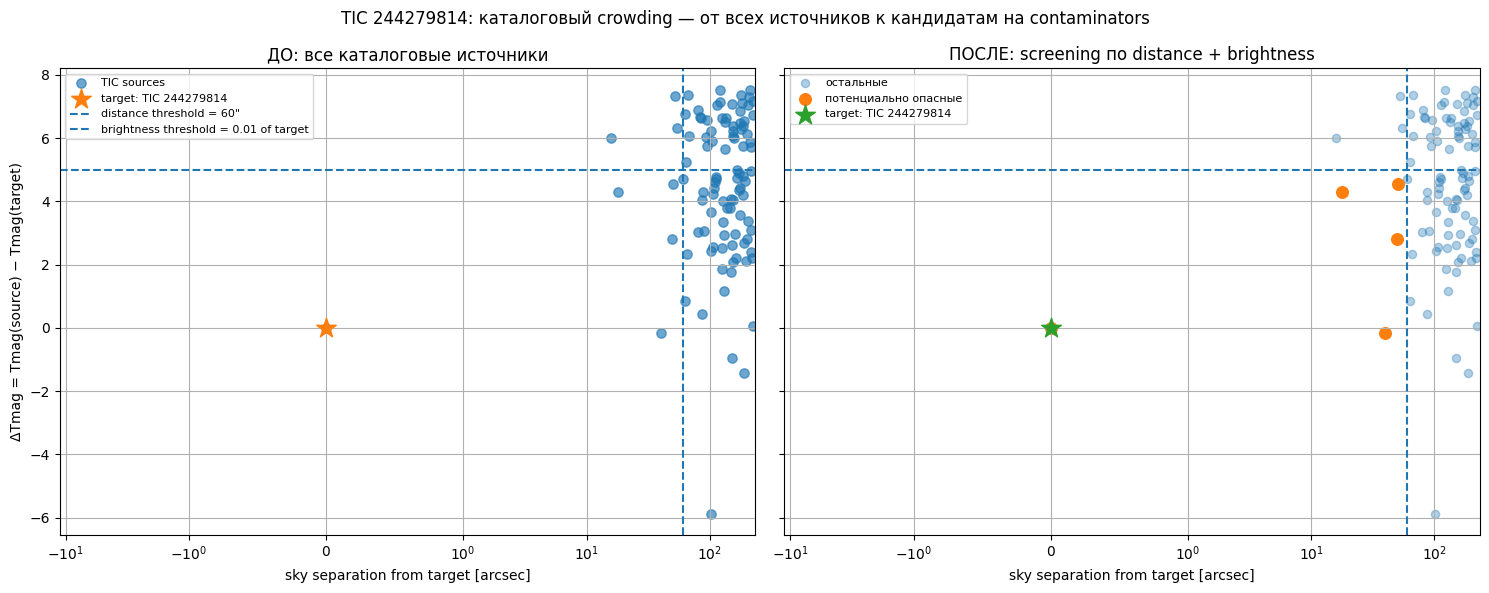

Всего TIC sources: 100
После screening: 5
Учебные пороги: separation <= 60 arcsec и flux ratio >= 0.01.
Важно: это screening, а не измерение contamination. PRF/throughput и фактическое попадание flux в aperture пока не рассчитаны.


In [17]:
# Screening TIC sources by sky separation + brightness.
# Это намеренно НЕ WCS-to-TPF преобразование.
# Здесь мы хотим показать только: кто близко и кто достаточно яркий.

if tic_df is not None and len(tic_df) > 0:
    catalog_plot = tic_df.copy().dropna(subset=["ra", "dec", "Tmag"])

    target_tmag = float(star.tess_mag)
    sky_target = SkyCoord(
        ra=float(star.coords[0]) * u.deg,
        dec=float(star.coords[1]) * u.deg
    )
    sky_neigh = SkyCoord(
        ra=catalog_plot["ra"].to_numpy() * u.deg,
        dec=catalog_plot["dec"].to_numpy() * u.deg
    )

    catalog_plot["sep_arcsec"] = sky_target.separation(sky_neigh).arcsec
    catalog_plot["delta_T"] = catalog_plot["Tmag"] - target_tmag

    # Учебные screening thresholds, не универсальные TESS thresholds.
    SEP_LIMIT = 60.0       # arcsec
    BRIGHT_LIMIT = 0.01    # flux ratio = 1%

    catalog_plot["flux_ratio_to_target"] = 10**(
        -0.4 * catalog_plot["delta_T"]
    )
    catalog_plot["potentially_dangerous"] = (
        (catalog_plot["sep_arcsec"] <= SEP_LIMIT) &
        (catalog_plot["flux_ratio_to_target"] >= BRIGHT_LIMIT)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # BEFORE
    ax = axes[0]
    ax.scatter(
        catalog_plot["sep_arcsec"],
        catalog_plot["delta_T"],
        s=45, alpha=0.65, label="TIC sources"
    )
    ax.scatter(
        0, 0, marker="*", s=220,
        label="target: TIC 244279814", zorder=5
    )
    ax.axvline(SEP_LIMIT, ls="--", label=f"distance threshold = {SEP_LIMIT:.0f}\"")
    ax.axhline(
        -2.5 * np.log10(BRIGHT_LIMIT), ls="--",
        label=f"brightness threshold = {BRIGHT_LIMIT:.2f} of target"
    )
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel("sky separation from target [arcsec]")
    ax.set_ylabel("ΔTmag = Tmag(source) − Tmag(target)")
    ax.set_title("ДО: все каталоговые источники")
    ax.legend(fontsize=8)

    # AFTER
    ax = axes[1]
    risky = catalog_plot[catalog_plot["potentially_dangerous"]]
    safe = catalog_plot[~catalog_plot["potentially_dangerous"]]

    ax.scatter(
        safe["sep_arcsec"], safe["delta_T"],
        s=35, alpha=0.35, label="остальные"
    )
    ax.scatter(
        risky["sep_arcsec"], risky["delta_T"],
        s=70, label="потенциально опасные"
    )
    ax.scatter(
        0, 0, marker="*", s=220,
        label="target: TIC 244279814", zorder=5
    )
    ax.axvline(SEP_LIMIT, ls="--")
    ax.axhline(-2.5 * np.log10(BRIGHT_LIMIT), ls="--")
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel("sky separation from target [arcsec]")
    ax.set_title("ПОСЛЕ: screening по distance + brightness")
    ax.legend(fontsize=8)

    plt.suptitle(
        "TIC 244279814: каталоговый crowding — от всех источников к кандидатам на contaminators"
    )
    plt.tight_layout()
    plt.show()

    print(f"Всего TIC sources: {len(catalog_plot)}")
    print(f"После screening: {len(risky)}")
    print(
        f"Учебные пороги: separation <= {SEP_LIMIT:.0f}" 
        f" arcsec и flux ratio >= {BRIGHT_LIMIT:.2f}."
    )
    print(
        "Важно: это screening, а не измерение contamination. "
        "PRF/throughput и фактическое попадание flux в aperture пока не рассчитаны."
    )
else:
    print("Нет TIC sources для screening.")


## 7.2. Gaia: как найти уже известные переменные/астрофизические источники?

Gaia DR3 содержит отдельные результаты классификации переменных источников.

Для deblending это полезная дополнительная информация:

> если рядом уже известен eclipsing binary, RR Lyrae, LPV, AGN, CV и т. п., его сигнал нельзя без проверки считать новым транзитом target.

Это не означает «автоматически удалить объект». Полезнее сохранить информацию как **quality flag** и посмотреть, насколько источник близок и яркий.

Если для Gaia source нет classification, это означает только **«Gaia не дала нам классификацию»**, а не «источник точно не переменный».


In [18]:
# Join Gaia DR3 variability classifications directly in ADQL.
# Такой JOIN избегает KeyError при промежуточном DataFrame merge.

if gaia_df is not None and len(gaia_df) > 0 and "source_id" in gaia_df.columns:
    try:
        ids = (
            gaia_df["source_id"].dropna()
            .astype("int64").unique().tolist()
        )
        ids_sql = ",".join(str(x) for x in ids[:200])

        query = f"""
        SELECT
            g.source_id,
            v.best_class_name,
            v.best_class_score
        FROM gaiadr3.gaia_source AS g
        LEFT JOIN gaiadr3.vari_classifier_result AS v
            ON g.source_id = v.source_id
        WHERE g.source_id IN ({ids_sql})
        """

        var_job = Gaia.launch_job_async(query)
        gaia_var = var_job.get_results().to_pandas()

        source_col = next(
            (c for c in gaia_var.columns
             if c.lower() == "source_id" or c.lower().endswith(".source_id")),
            None
        )
        if source_col is not None and source_col != "source_id":
            gaia_var = gaia_var.rename(columns={source_col: "source_id"})

        keep = [c for c in ["source_id", "best_class_name", "best_class_score"]
                if c in gaia_var.columns]

        if "source_id" not in keep:
            raise KeyError("В ответе Gaia не найден source_id.")

        gaia_df = gaia_df.merge(
            gaia_var[keep].drop_duplicates("source_id"),
            on="source_id", how="left"
        )

        for col in ["best_class_name", "best_class_score"]:
            if col not in gaia_df.columns:
                gaia_df[col] = np.nan

    except Exception as e:
        print("Gaia variability classification не получена:", repr(e))
        gaia_df["best_class_name"] = np.nan
        gaia_df["best_class_score"] = np.nan

    display(
        gaia_df[
            [c for c in [
                "source_id", "phot_g_mean_mag",
                "parallax", "ruwe",
                "best_class_name", "best_class_score"
            ] if c in gaia_df.columns]
        ].head(20)
    )
else:
    print("Нет Gaia sources для классификации.")


Нет Gaia sources для классификации.


## 7.3. Как оценивать «засорённость»: не одним числом

После screening остаются **кандидаты**, а не доказанные contaminators.

Для каждого кандидата полезно проверять:

1. **Distance** — расстояние до target.
2. **Brightness** — отношение полного flux к target.
3. **WCS position** — положение в TPF.
4. **Aperture overlap** — геометрическое пересечение с aperture.
5. **Known variability** — есть ли известная переменность.
6. **Event-level verification** — совпадает ли положение с difference signal.

Главное:

$$
\text{brightness ratio} \neq \text{contamination}.
$$

Точное contamination требует spatial throughput `α_i`, а `α_i` зависит от положения источника относительно pixels и от PSF/PRF.


In [19]:
# Геометрический WCS-screening для TIC sources.
# Это ещё НЕ α_i: nearest-pixel test нужен только для первичного отбора.

def add_wcs_positions(df, ra_col="ra", dec_col="dec"):
    out = df.copy()
    rows, cols = [], []

    for ra, dec in zip(out[ra_col], out[dec_col]):
        if np.isfinite(ra) and np.isfinite(dec):
            r, c = world_to_tpf(float(ra), float(dec))
        else:
            r, c = np.nan, np.nan
        rows.append(r)
        cols.append(c)

    out["tpf_row"] = rows
    out["tpf_col"] = cols

    h, w = tpf_shape
    out["inside_tpf"] = (
        (out["tpf_row"] >= -0.5) & (out["tpf_row"] <= h-0.5) &
        (out["tpf_col"] >= -0.5) & (out["tpf_col"] <= w-0.5)
    )

    ap = np.asarray(data.aperture)
    nearest_in_ap = np.zeros(len(out), dtype=bool)
    valid = np.isfinite(out["tpf_row"]) & np.isfinite(out["tpf_col"])
    rr = np.rint(out.loc[valid, "tpf_row"].to_numpy()).astype(int)
    cc = np.rint(out.loc[valid, "tpf_col"].to_numpy()).astype(int)
    ok = (rr >= 0) & (rr < ap.shape[0]) & (cc >= 0) & (cc < ap.shape[1])
    inds = np.where(valid)[0][ok]
    nearest_in_ap[inds] = ap[rr[ok], cc[ok]] > 0
    out["nearest_pixel_in_aperture"] = nearest_in_ap
    return out

if tic_df is not None and len(tic_df):
    tic_risk = add_wcs_positions(tic_df.dropna(subset=["ra","dec"]).copy())
    sky_target = SkyCoord(
        ra=float(star.coords[0])*u.deg,
        dec=float(star.coords[1])*u.deg
    )
    sky_neigh = SkyCoord(
        ra=tic_risk["ra"].to_numpy()*u.deg,
        dec=tic_risk["dec"].to_numpy()*u.deg
    )
    tic_risk["sep_arcsec"] = sky_target.separation(sky_neigh).arcsec
    tic_risk["delta_T"] = tic_risk["Tmag"] - float(star.tess_mag)
    tic_risk["flux_ratio_to_target"] = 10**(-0.4*tic_risk["delta_T"])

    tic_risk["bright_candidate"] = tic_risk["flux_ratio_to_target"] >= 0.01
    tic_risk["close_candidate"] = tic_risk["sep_arcsec"] <= 60
    tic_risk["potentially_dangerous"] = (
        tic_risk["bright_candidate"] &
        tic_risk["close_candidate"] &
        tic_risk["nearest_pixel_in_aperture"]
    )

    display(
        tic_risk[
            ["ID","Tmag","sep_arcsec","delta_T","flux_ratio_to_target",
             "tpf_row","tpf_col","inside_tpf",
             "nearest_pixel_in_aperture","potentially_dangerous"]
        ].sort_values(
            ["potentially_dangerous","flux_ratio_to_target"],
            ascending=[False,False]
        ).head(20)
    )

    print("nearest_pixel_in_aperture — только геометрический screening.")
    print("Точная α_i требует PSF/PRF или эмпирической pixel-throughput оценки.")
else:
    print("Нет TIC sources.")

# Для Gaia используем уже propagated coordinates.
if "gaia_epoch" in globals() and len(gaia_epoch):
    gaia_risk = gaia_epoch.copy()
    sky_gaia = SkyCoord(
        ra=gaia_risk["ra_tess_epoch"].to_numpy()*u.deg,
        dec=gaia_risk["dec_tess_epoch"].to_numpy()*u.deg
    )
    gaia_risk["sep_arcsec"] = sky_target.separation(sky_gaia).arcsec

    if "phot_g_mean_mag" in gaia_risk.columns:
        gaia_risk["delta_G"] = (
            gaia_risk["phot_g_mean_mag"] - float(star.tess_mag)
        )
        gaia_risk["G_flux_ratio_to_target"] = 10**(-0.4*gaia_risk["delta_G"])

    display(
        gaia_risk[
            [c for c in [
                "source_id","phot_g_mean_mag","sep_arcsec",
                "G_flux_ratio_to_target","tpf_row","tpf_col",
                "best_class_name"
            ] if c in gaia_risk.columns]
        ].sort_values("sep_arcsec").head(20)
    )


,ID,Tmag,sep_arcsec,delta_T,flux_ratio_to_target,tpf_row,tpf_col,inside_tpf,nearest_pixel_in_aperture,potentially_dangerous
0,244279814,13.30410,0.000000,0.00000,1.000000,6.195091,6.203749,True,True,True
2,244279812,17.59170,17.847532,4.28760,0.019273,7.039752,6.372774,True,True,True
26,244279829,7.42618,101.548990,-5.87792,224.475010,1.503146,7.671892,True,False,False
80,213033891,11.87560,187.795901,-1.42850,3.727348,-0.802305,11.973702,False,False,False
54,244279797,12.34150,149.885829,-0.96260,2.426834,10.924221,11.592169,True,False,False
3,244279809,13.15080,39.870658,-0.15330,1.151649,8.024747,5.588897,True,False,False
98,244279784,13.35880,222.559604,0.05470,0.950867,16.856216,4.660567,False,False,False
19,244279826,13.73180,86.282309,0.42770,0.674404,2.090296,6.975764,True,False,False
10,244279813,14.16440,63.381651,0.86030,0.452772,7.056870,3.292708,True,False,False
46,244279800,14.45900,129.899540,1.15490,0.345176,11.455079,2.772222,True,False,False


nearest_pixel_in_aperture — только геометрический screening.
Точная α_i требует PSF/PRF или эмпирической pixel-throughput оценки.


,phot_g_mean_mag,sep_arcsec,G_flux_ratio_to_target,tpf_row,tpf_col
0,13.741033,0.094931,0.668693,6.195159,6.208281
1,19.681198,15.755990,0.002813,6.435539,5.487990
2,18.086456,17.783928,0.012220,7.036890,6.371476
3,13.680758,39.456903,0.706866,8.000077,5.578710
4,16.618971,49.584741,0.047212,4.773216,8.121173
5,18.199842,50.647104,0.011008,5.379300,3.929544
6,20.762487,52.337772,0.001039,3.817682,7.079598
7,20.254189,54.550498,0.001659,4.235690,7.962886
8,18.577436,60.437959,0.007774,4.438184,3.910624
9,20.651087,63.055676,0.001151,5.802321,9.192657


## 7.4. Как практически получить поток target и соседей для C?

Здесь важно разделить две величины.

### 1. Полный поток источника

Если известна TESS magnitude:

$$
F_i \propto 10^{-0.4T_i}.
$$

Абсолютная калибровка не нужна, потому что для `C` важны отношения потоков:

$$
\frac{F_i}{F_t}=10^{-0.4(T_i-T_t)}.
$$

### 2. Какая часть потока попала в aperture?

Для этого вводим:

$$
\alpha_i=\text{доля потока источника }i\text{ в aperture}.
$$

Тогда эффективный поток источника в нашей photometry:

$$
F_{i,ap}=\alpha_iF_i.
$$

И:

$$
C=\frac{\sum_{i\ne t}\alpha_iF_i}
        {\alpha_tF_t},
\qquad
c=\frac{1}{1+C}.
$$

Это и есть практический смысл `C` и `c`.

В следующей ячейке для **учебной оценки** используется тот же Gaussian-PSF подход, что и в `gaia_overlay.py`. Это специально отмечено как модельная оценка, потому что полноценный PRF deblending здесь не выполняется.


In [20]:
# Учебная оценка C и c на основе TIC Tmag + WCS + Gaussian PSF.
# Важно: это не точный PRF deblend.
#
# Здесь Gaussian-PSF расчёт реализован прямо в notebook, чтобы ячейка
# не зависела от отдельного файла aperture_contamination.py.
PSF_SIGMA_PX = 0.74

def aperture_fraction(row, col, aperture, sigma=PSF_SIGMA_PX):
    """Доля гауссового PSF источника, попавшая в заданную aperture."""
    aperture = np.asarray(aperture, dtype=float)
    height, width = aperture.shape
    rows = np.arange(height)[:, None]
    cols = np.arange(width)[None, :]
    psf = np.exp(-((rows - row)**2 + (cols - col)**2) / (2.0 * sigma**2))
    total = np.sum(psf)
    if total <= 0:
        return 0.0
    return float(np.sum(psf * aperture) / total)

if tic_df is not None and len(tic_df):
    crowd = add_wcs_positions(
        tic_df.dropna(subset=["ra","dec","Tmag"]).copy()
    )

    target_tmag = float(star.tess_mag)
    target_row = float(target_row_wcs)
    target_col = float(target_col_wcs)

    # Относительный полный flux.
    crowd["flux_ratio_to_target"] = 10**(
        -0.4 * (crowd["Tmag"] - target_tmag)
    )

    # Gaussian-PSF fraction falling into the actual aperture.
    ap = np.asarray(data.aperture, dtype=float)
    crowd["alpha_in_aperture"] = [
        aperture_fraction(r, c, ap, PSF_SIGMA_PX)
        for r, c in zip(crowd["tpf_row"], crowd["tpf_col"])
    ]

    crowd["effective_flux_ratio"] = (
        crowd["flux_ratio_to_target"] *
        crowd["alpha_in_aperture"]
    )

    # Identify target row in TIC by the TIC ID when possible.
    target_id = int(star.tic)
    if "ID" in crowd.columns:
        is_target = crowd["ID"].astype("Int64") == target_id
    else:
        is_target = np.zeros(len(crowd), dtype=bool)

    # If the target row is not present, use WCS-derived target throughput.
    alpha_target = aperture_fraction(
        target_row, target_col, ap, PSF_SIGMA_PX
    )

    if is_target.any():
        alpha_target = float(
            crowd.loc[is_target, "alpha_in_aperture"].iloc[0]
        )

    neighbors = crowd[~is_target].copy()
    Fcont_over_Ftarget = float(
        neighbors["effective_flux_ratio"].sum() / alpha_target
    )
    C_model = Fcont_over_Ftarget
    c_model = 1.0 / (1.0 + C_model)

    display(
        neighbors[
            ["ID","Tmag","tpf_row","tpf_col",
             "flux_ratio_to_target","alpha_in_aperture",
             "effective_flux_ratio"]
        ].sort_values("effective_flux_ratio", ascending=False).head(15)
    )

    print(f"PSF model: Gaussian, sigma = {PSF_SIGMA_PX:.3f} px")
    print(f"Target aperture throughput alpha_t = {alpha_target:.4f}")
    print(f"C_model = {C_model:.4f}")
    print(f"c_model = 1/(1+C) = {c_model:.4f}")
    print(
        "Интерпретация: c — оценённая доля собственного target flux "
        "среди постоянного flux в photometry."
    )
    print(
        "Ограничение: alpha_i получена из упрощённой PSF-модели; "
        "это не полноценный TESS PRF/scene fit."
    )
else:
    print("Нет TIC sources.")

,ID,Tmag,tpf_row,tpf_col,flux_ratio_to_target,alpha_in_aperture,effective_flux_ratio
3,244279809,13.15080,8.024747,5.588897,1.151649,1.046353e-01,0.120503
2,244279812,17.59170,7.039752,6.372774,0.019273,4.185258e-01,0.008066
10,244279813,14.16440,7.056870,3.292708,0.452772,1.103495e-02,0.004996
4,244279818,16.12690,4.778160,8.118518,0.074281,4.501689e-02,0.003344
1,672207272,19.31850,6.442322,5.485619,0.003929,5.638739e-01,0.002215
5,672207271,17.86580,5.379802,3.929458,0.014973,8.537426e-02,0.001278
12,244279825,15.64750,3.057100,5.748835,0.115515,8.449574e-03,0.000976
8,672207270,18.01530,4.439439,3.909890,0.013047,3.043416e-02,0.000397
26,244279829,7.42618,1.503146,7.671892,224.475010,9.466740e-07,0.000213
7,672207249,19.63840,4.235263,7.959826,0.002926,2.864477e-02,0.000084


PSF model: Gaussian, sigma = 0.740 px
Target aperture throughput alpha_t = 0.6534
C_model = 0.2178
c_model = 1/(1+C) = 0.8212
Интерпретация: c — оценённая доля собственного target flux среди постоянного flux в photometry.
Ограничение: alpha_i получена из упрощённой PSF-модели; это не полноценный TESS PRF/scene fit.


## 7.5. WCS overlay: проверяем, что координаты действительно легли на TPF

Теперь можно визуально проверить весь путь:

**Gaia → proper motion to TESS epoch → WCS → TPF pixels.**

Это гораздо полезнее, чем просто таблица RA/Dec: мы видим, попадает ли каталоговый источник туда, где физически находится его flux на TPF.


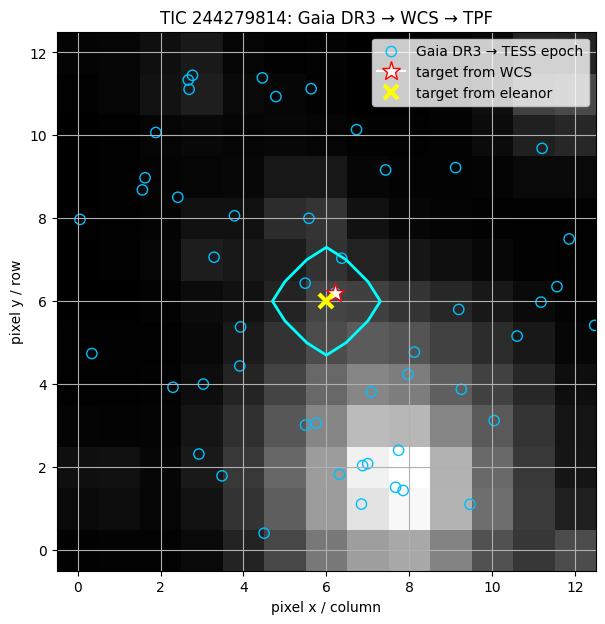

Белая звезда = target по WCS; жёлтый крест = target из eleanor. Их близость — полезная sanity check.


In [21]:
if "gaia_epoch" in globals() and len(gaia_epoch):
    fig, ax = plt.subplots(figsize=(8, 7))

    ax.imshow(
        frame_median, origin="lower", cmap="gray",
        norm=positive_log_norm(frame_median)
    )
    ap = np.asarray(data.aperture)
    if np.nansum(ap) > 0:
        ax.contour(ap, levels=[0.5], colors="cyan", linewidths=2)

    inside = (
        (gaia_epoch["tpf_row"] >= -0.5) &
        (gaia_epoch["tpf_row"] <= tpf_shape[0]-0.5) &
        (gaia_epoch["tpf_col"] >= -0.5) &
        (gaia_epoch["tpf_col"] <= tpf_shape[1]-0.5)
    )

    ax.scatter(
        gaia_epoch.loc[inside, "tpf_col"],
        gaia_epoch.loc[inside, "tpf_row"],
        s=55, facecolors="none", edgecolors="deepskyblue",
        label="Gaia DR3 → TESS epoch"
    )

    ax.plot(
        target_col_wcs, target_row_wcs,
        marker="*", markersize=14, color="white",
        markeredgecolor="red", label="target from WCS"
    )

    ax.plot(
        target_x_demo, target_y_demo,
        "x", ms=10, mew=3, color="yellow",
        label="target from eleanor"
    )

    ax.set_xlim(-0.5, tpf_shape[1]-0.5)
    ax.set_ylim(-0.5, tpf_shape[0]-0.5)
    ax.set_xlabel("pixel x / column")
    ax.set_ylabel("pixel y / row")
    ax.set_title("TIC 244279814: Gaia DR3 → WCS → TPF")
    ax.legend()
    plt.show()

    print(
        "Белая звезда = target по WCS; жёлтый крест = target из eleanor. "
        "Их близость — полезная sanity check."
    )


# 8. От «рядом есть источник» к «он действительно создал событие»

TIC/Gaia отвечают на вопрос:

> «Какие источники потенциально могут загрязнять photometry?»

Но для транзитного/затменного события нужен более сильный вопрос:

> **«Какой источник реально изменился?»**

Для этого переходим от каталога к временно разделённым TPF.

Мы выберем:

- **OOE (out of eclipse)** — кадры вне события;
- **IE (in eclipse)** — кадры во время события.

Затем сравним их spatially.

Это и есть идея **difference imaging / difference photometry**.


## 8.1 Сначала выбираем реальное событие

Автоматический поиск минимумов нужен только для того, чтобы быстро получить список кандидатов.

**Окончательный event выбираем по графику**, потому что для difference image важно, чтобы:

- событие было настоящим;
- окно IE действительно покрывало eclipse;
- OOE не попадало на соседнее событие;
- в IE и OOE было достаточно cadences.

Это не мелочь: плохие окна дадут плохую difference image даже при идеальном коде.


In [22]:
# После просмотра light curve задаём один реальный eclipse.
EVENT_CENTER = 2181.7

print("TIC 244279814, Sector 32")
print("Текущий выбранный event center:", EVENT_CENTER)


TIC 244279814, Sector 32
Текущий выбранный event center: 2181.7


## 8.2 Как читать IE/OOE на двух масштабах?

Здесь специально показываем **два масштаба одновременно**.

### Верхний график — весь Sector 32

Он нужен, чтобы не потерять из виду:

- общий уровень flux;
- долгопериодные изменения;
- систематические тренды;
- другие события и выбросы.

То есть мы не рассматриваем выбранный eclipse изолированно от всей light curve.

### Нижний график — увеличенный фрагмент

Здесь уже проверяем конкретные окна:

- **IE** — кадры внутри выбранного eclipse;
- **OOE** — кадры вне eclipse;
- между ними оставлен `OOE_GAP`, чтобы не захватить края события.

`EVENT_HALF_WIDTH`, `OOE_GAP` и `OOE_HALF_WIDTH` — это **временные интервалы**, а не периоды звезды.

Такой двухмасштабный график лучше подходит для выбора IE/OOE: сначала понимаем глобальный контекст, затем проверяем конкретное событие.


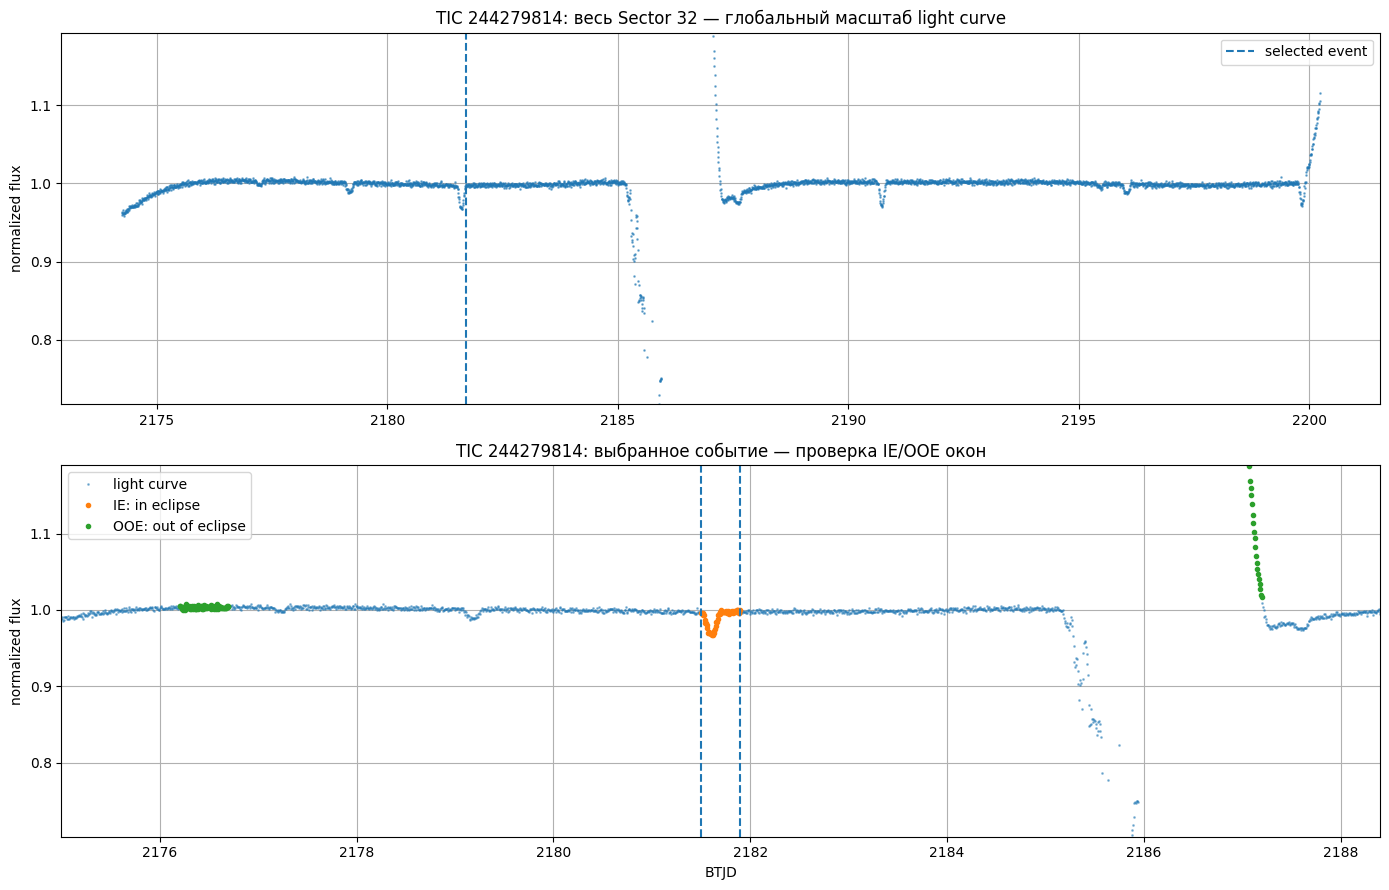

Total cadences: 3600
Finite TPF cadences: 3600
IE cadences: 58
OOE cadences: 108


In [23]:
# Проверяем выбранные IE/OOE окна сразу в двух масштабах:
# 1) весь сектор — чтобы видеть глобальные тренды;
# 2) локальное окно — чтобы проверить конкретное событие.

time_all = np.asarray(data.time, dtype=float)
tpf_all = np.asarray(data.tpf, dtype=float)
lc = np.asarray(data.corr_flux, dtype=float)

q_lc = np.isfinite(time_all) & np.isfinite(lc)
lc_norm = lc / np.nanmedian(lc[q_lc])

EVENT_HALF_WIDTH = 0.2
OOE_GAP = 5
OOE_HALF_WIDTH = 0.5

finite_tpf = np.isfinite(time_all)
if tpf_all.ndim == 3:
    finite_tpf &= np.isfinite(tpf_all).any(axis=(1, 2))

ie = (
    finite_tpf &
    (np.abs(time_all - EVENT_CENTER) <= EVENT_HALF_WIDTH)
)

ooe = (
    finite_tpf &
    (
        (
            (time_all >= EVENT_CENTER - OOE_GAP - OOE_HALF_WIDTH) &
            (time_all < EVENT_CENTER - OOE_GAP)
        )
        |
        (
            (time_all > EVENT_CENTER + OOE_GAP) &
            (time_all <= EVENT_CENTER + OOE_GAP + OOE_HALF_WIDTH)
        )
    )
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# GLOBAL VIEW
ax = axes[0]
ax.plot(time_all[q_lc], lc_norm[q_lc], ".", ms=1.8, alpha=0.55)
ax.axvline(EVENT_CENTER, ls="--", label="selected event")
ax.set_ylabel("normalized flux")
ax.set_title(
    "TIC 244279814: весь Sector 32 — глобальный масштаб light curve"
)
# Robust limits: suppress extreme outliers but keep long-term trends visible.
glo = lc_norm[q_lc]
glo_lo, glo_hi = np.nanpercentile(glo, [1, 99])
glo_pad = max(0.002, 0.08 * (glo_hi - glo_lo))
ax.set_ylim(glo_lo - glo_pad, glo_hi + glo_pad)
ax.legend()

# LOCAL VIEW
ax = axes[1]
ax.plot(time_all[q_lc], lc_norm[q_lc], ".", ms=2, alpha=0.45, label="light curve")
ax.plot(time_all[ie], lc_norm[ie], ".", ms=6, label="IE: in eclipse")
ax.plot(time_all[ooe], lc_norm[ooe], ".", ms=6, label="OOE: out of eclipse")
ax.axvline(EVENT_CENTER - EVENT_HALF_WIDTH, ls="--")
ax.axvline(EVENT_CENTER + EVENT_HALF_WIDTH, ls="--")

window = EVENT_HALF_WIDTH + OOE_GAP + OOE_HALF_WIDTH + 1
ax.set_xlim(EVENT_CENTER - window, EVENT_CENTER + window)
local = q_lc & (
    (time_all >= EVENT_CENTER - window) &
    (time_all <= EVENT_CENTER + window)
)
local_flux = lc_norm[local]
if np.any(local):
    lo, hi = np.nanpercentile(local_flux, [2, 98])
    pad = max(0.001, 0.12 * (hi - lo))
    ax.set_ylim(lo - pad, hi + pad)

ax.set_xlabel("BTJD")
ax.set_ylabel("normalized flux")
ax.set_title(
    "TIC 244279814: выбранное событие — проверка IE/OOE окон"
)
ax.legend()

plt.tight_layout()
plt.show()

print("Total cadences:", len(time_all))
print("Finite TPF cadences:", finite_tpf.sum())
print("IE cadences:", ie.sum())
print("OOE cadences:", ooe.sum())


## 8.3. Difference image: пошагово

### Что мы делаем?

1. Выбираем реальное событие.
2. Делим кадры на IE (in eclipse) и OOE (out of eclipse).
3. Усредняем TPF отдельно.
4. Вычитаем:

$$
I_{diff}=I_{OOE}-I_{IE}.
$$

Для eclipse положительный `diff` означает: **в этом месте во время события пропал flux**.

### Почему это полезно?

Постоянный сосед в идеале вычитается:

`OOE: target + neighbor`

минус

`IE: dimmed target + neighbor`

оставляет переменную часть target.

Поэтому difference imaging прежде всего отвечает:

> **Где произошло изменение?**

### Почему добавляем логарифмическую картинку?

Difference image бывает signed, поэтому весь `I_diff` нельзя показать обычным логарифмом.

Поэтому показываем одновременно:

- signed linear `I_diff` — знак изменения;
- `positive(diff)` в `LogNorm` — слабые и сильные положительные изменения на одной шкале.

Это особенно удобно, если сильный центральный сигнал визуально подавляет слабые структуры.

### Ограничения

- шум;
- imperfect alignment;
- выбор IE/OOE;
- несколько переменных источников;
- PRF/PSF structure.

Поэтому DIA — метод **локализации**, а не окончательного разделения источников.


Shapes: (3600, 13, 13) (3600,) (3600,)


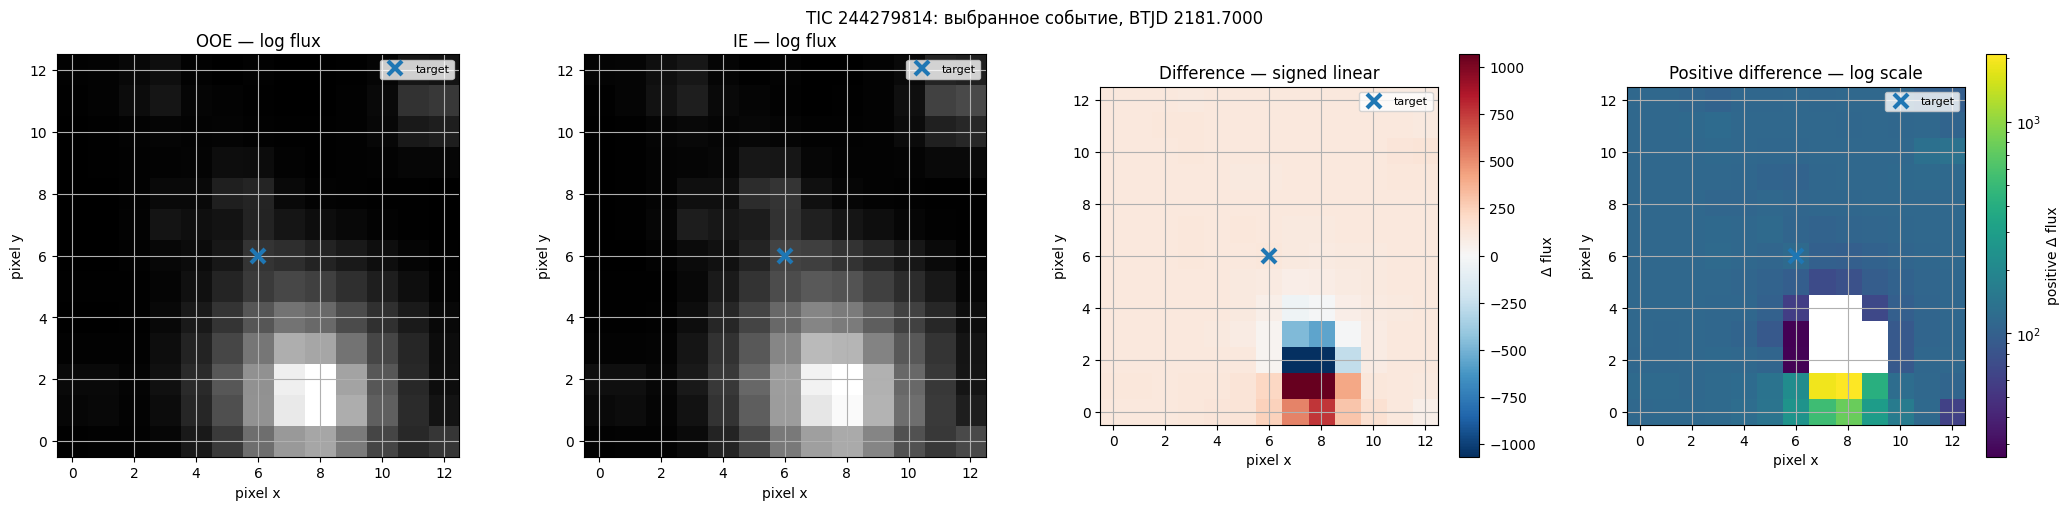

In [24]:
# Формируем OOE, IE и difference image.
# Повторно проверяем finite_tpf здесь, чтобы ячейка не зависела от
# отдельного промежуточного определения при предыдущем запуске notebook.
finite_tpf = np.isfinite(time_all)
if tpf_all.ndim == 3:
    finite_tpf &= np.isfinite(tpf_all).all(axis=(1, 2))
else:
    raise ValueError(f"Ожидался TPF формы (N, y, x), получено {tpf_all.shape}")

valid = finite_tpf

tpf_valid = tpf_all[valid]
ie_valid = ie[valid]
ooe_valid = ooe[valid]

print("Shapes:", tpf_valid.shape, ie_valid.shape, ooe_valid.shape)

if ie_valid.sum() == 0 or ooe_valid.sum() == 0:
    raise ValueError("IE или OOE не содержит valid cadences.")

ie_img = np.nanmean(tpf_valid[ie_valid], axis=0)
ooe_img = np.nanmean(tpf_valid[ooe_valid], axis=0)
diff_img = ooe_img - ie_img

v = np.nanpercentile(np.abs(diff_img), 98)
positive_diff = np.clip(diff_img, 0, None)

fig, axes = plt.subplots(1, 4, figsize=(21, 5))

axes[0].imshow(ooe_img, origin="lower", cmap="gray",
                norm=positive_log_norm(ooe_img))
axes[0].plot(target_x_demo, target_y_demo, "x", ms=10, mew=3,
             label="target")
axes[0].set_title("OOE — log flux")

axes[1].imshow(ie_img, origin="lower", cmap="gray",
                norm=positive_log_norm(ie_img))
axes[1].plot(target_x_demo, target_y_demo, "x", ms=10, mew=3,
             label="target")
axes[1].set_title("IE — log flux")

im = axes[2].imshow(diff_img, origin="lower", cmap="RdBu_r",
                    vmin=-v, vmax=v)
axes[2].plot(target_x_demo, target_y_demo, "x", ms=10, mew=3,
             label="target")
axes[2].set_title("Difference — signed linear")
plt.colorbar(im, ax=axes[2], label="Δ flux")

im = axes[3].imshow(
    positive_diff, origin="lower", cmap="viridis",
    norm=positive_log_norm(positive_diff, low=0, high=99.5)
)
axes[3].plot(target_x_demo, target_y_demo, "x", ms=10, mew=3,
             label="target")
axes[3].set_title("Positive difference — log scale")
plt.colorbar(im, ax=axes[3], label="positive Δ flux")

for ax in axes:
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle(f"TIC 244279814: выбранное событие, BTJD {EVENT_CENTER:.4f}")
plt.tight_layout()
plt.show()


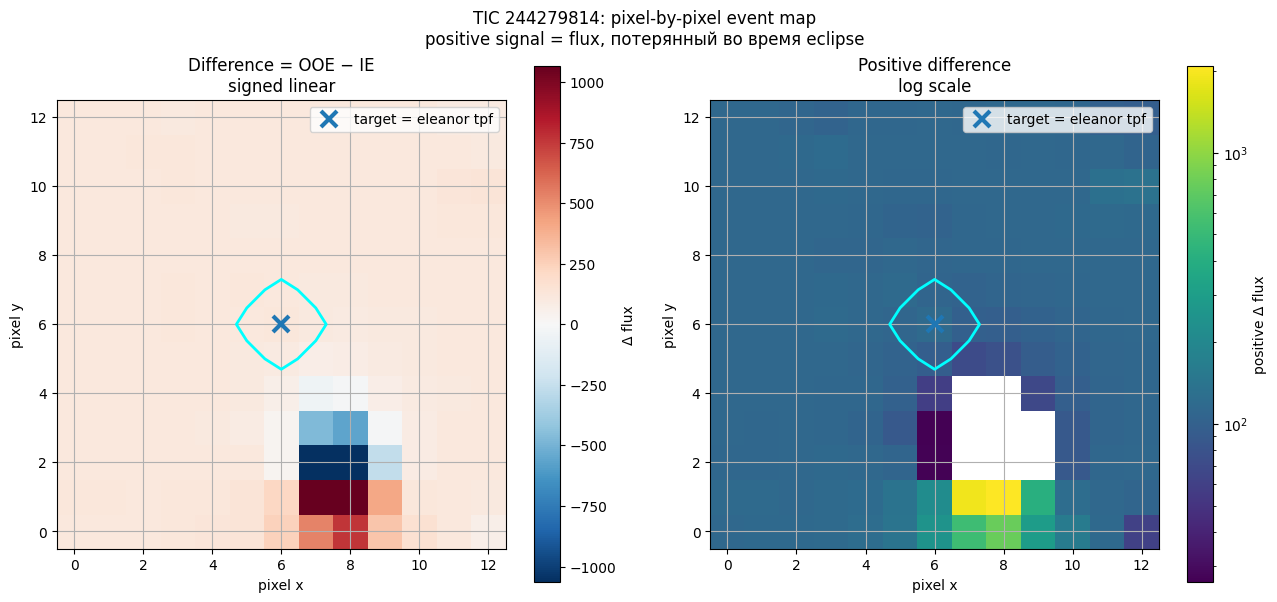

In [25]:
# Pixel-by-pixel event map.
# Signed difference показывает знак, а positive part в log scale
# помогает увидеть слабые структуры вокруг сильного сигнала.

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

im = axes[0].imshow(
    diff_img, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v
)
axes[0].plot(target_x_demo, target_y_demo, "x", ms=11, mew=3,
             label="target = eleanor tpf")
axes[0].contour(np.asarray(data.aperture), levels=[0.5],
                colors="cyan", linewidths=2)
axes[0].set_title("Difference = OOE − IE\nsigned linear")
plt.colorbar(im, ax=axes[0], label="Δ flux")

im = axes[1].imshow(
    np.clip(diff_img, 0, None), origin="lower", cmap="viridis",
    norm=positive_log_norm(np.clip(diff_img, 0, None), low=0, high=99.5)
)
axes[1].plot(target_x_demo, target_y_demo, "x", ms=11, mew=3,
             label="target = eleanor tpf")
axes[1].contour(np.asarray(data.aperture), levels=[0.5],
                colors="cyan", linewidths=2)
axes[1].set_title("Positive difference\nlog scale")
plt.colorbar(im, ax=axes[1], label="positive Δ flux")

for ax in axes:
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    ax.legend()

plt.suptitle(
    "TIC 244279814: pixel-by-pixel event map\n"
    "positive signal = flux, потерянный во время eclipse"
)
plt.tight_layout()
plt.show()


# 9. Flux-weighted centroid: где находится изменившийся flux?

После difference imaging у нас появляется spatial signal.

Теперь можно задать следующий вопрос:

> **Где находится центр этого изменившегося flux?**

Для этого используем flux-weighted centroid.

Если `F_i` — положительный difference flux в pixel `i`, то:

$$
x_c = \frac{\sum_i x_iF_i}{\sum_iF_i},
$$

$$
y_c = \frac{\sum_i y_iF_i}{\sum_iF_i}.
$$

### Как это работает?

1. Берём positive part difference image.
2. Каждый pixel получает вес, пропорциональный величине изменения flux.
3. Считаем среднее положение с этими весами.
4. Получаем координату центра переменного сигнала.

### Почему этот метод интересен?

Он почти не требует задавать форму PRF/PSF.

Это делает его хорошим **первым spatial diagnostic**.

### Что он НЕ делает?

Centroid не исправляет dilution и не разделяет light curve на несколько источников.

Он отвечает только на вопрос:

> **где находится переменная часть изображения?**

Если centroid близок к ожидаемому положению target, это поддерживает гипотезу, что сигнал связан с target. Если заметно смещён — появляется повод проверить contaminator.

Это диагностический признак, а не автоматическое доказательство.


## 9.1. Centroid простыми словами

**Centroid** — это «центр тяжести» света.

Если один pixel содержит много изменившегося flux, он сильнее влияет на итоговую координату. Поэтому:

$$
x_c=\frac{\sum x_iF_i}{\sum F_i},
\qquad
y_c=\frac{\sum y_iF_i}{\sum F_i}.
$$

Для difference image мы берём только положительный `diff`, потому что именно он соответствует flux, который исчез во время eclipse.

Centroid нужен не для исправления dilution, а для ответа на вопрос:

> **Где находится центр изменившегося flux?**

Если он заметно смещён от target, это повод проверить contaminator.

Важно: centroid — диагностический метод. Он не доказывает принадлежность сигнала target и не разделяет несколько источников.


In [26]:
positive = np.clip(diff_img, 0, None)
yy, xx = np.indices(positive.shape)

weight = np.nansum(positive)
if weight > 0:
    flux_cx = np.nansum(xx * positive) / weight
    flux_cy = np.nansum(yy * positive) / weight
else:
    flux_cx = flux_cy = np.nan

event_offset_pix = np.hypot(
    flux_cx - target_x_demo,
    flux_cy - target_y_demo
)

print(f"Target position from eleanor: x={target_x_demo:.3f}, y={target_y_demo:.3f}")
print(f"Event flux-weighted centroid:  x={flux_cx:.3f}, y={flux_cy:.3f}")
print(f"Offset in TPF pixels:          {event_offset_pix:.3f}")
print(f"Approx. offset on sky:         {event_offset_pix * 21:.1f} arcsec")


Target position from eleanor: x=6.000, y=6.000
Event flux-weighted centroid:  x=6.312, y=4.789
Offset in TPF pixels:          1.251
Approx. offset on sky:         26.3 arcsec


In [27]:
from scipy.optimize import least_squares

def gaussian2d(params, x, y):
    amp, x0, y0, sx, sy, offset = params
    return (
        offset
        + amp * np.exp(
            -0.5 * (((x - x0) / sx)**2 + ((y - y0) / sy)**2)
        )
    )

fit_mask = np.isfinite(positive)
xv = xx[fit_mask]
yv = yy[fit_mask]
zv = positive[fit_mask]

if np.nanmax(zv) > 0:
    p0 = [
        np.nanmax(zv),
        flux_cx,
        flux_cy,
        1.5,
        1.5,
        0.0
    ]

    def residuals(p):
        return gaussian2d(p, xv, yv) - zv

    fit = least_squares(
        residuals,
        p0,
        bounds=(
            [0, -10, -10, 0.2, 0.2, -np.inf],
            [np.inf, 20, 20, 20, 20, np.inf]
        )
    )

    amp, gauss_cx, gauss_cy, sx, sy, offset = fit.x
    model_img = gaussian2d(fit.x, xx, yy)
    resid_img = positive - model_img

    print(f"Gaussian centroid: x={gauss_cx:.3f}, y={gauss_cy:.3f}")
    print(f"Gaussian sigma_x={sx:.3f}, sigma_y={sy:.3f}")
else:
    gauss_cx = gauss_cy = np.nan
    model_img = np.zeros_like(positive)
    resid_img = positive.copy()


Gaussian centroid: x=6.477, y=5.529
Gaussian sigma_x=0.200, sigma_y=0.201


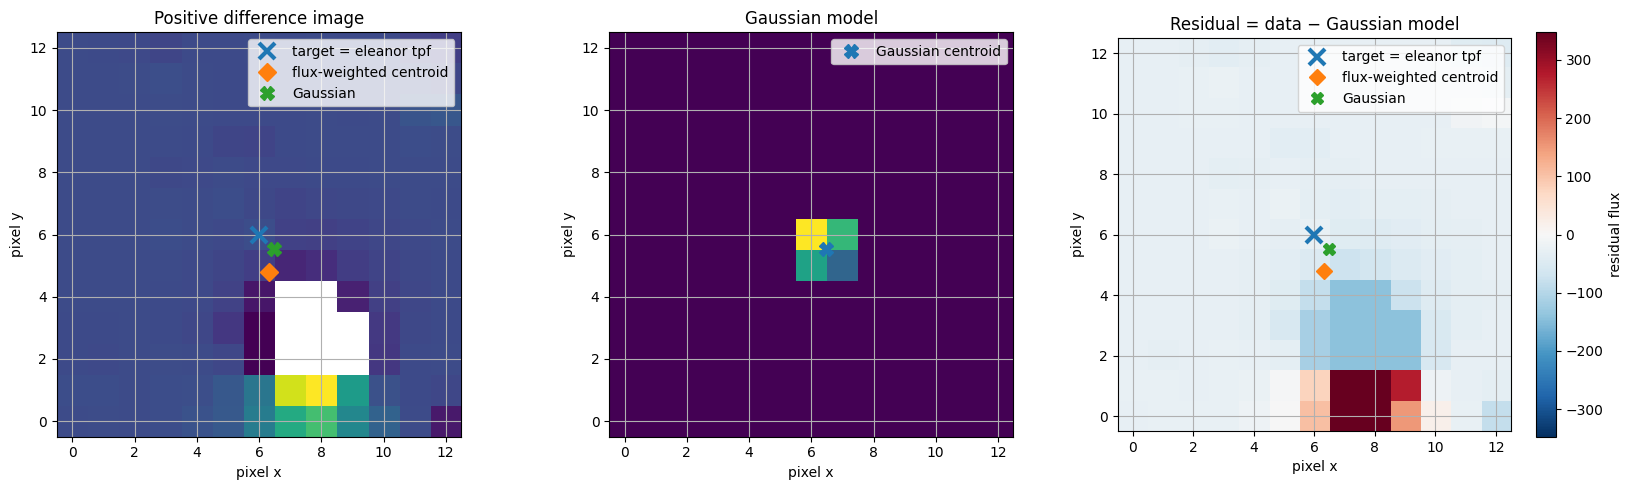

Peak positive signal: 2804
Residual RMS:         257.5
Residual peak:        2662
Residual RMS / signal peak: 0.092


In [28]:
# Сравниваем три spatial diagnostics:
# 1) target position из eleanor,
# 2) model-independent flux-weighted centroid,
# 3) Gaussian fit как model-dependent контроль.

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].imshow(
    positive,
    origin="lower",
    cmap="viridis",
    norm=positive_log_norm(positive)
)
axes[0].plot(
    target_x_demo, target_y_demo,
    "x", ms=11, mew=3,
    label="target = eleanor tpf"
)
axes[0].plot(
    flux_cx, flux_cy,
    "D", ms=9, label="flux-weighted centroid"
)
axes[0].plot(
    gauss_cx, gauss_cy,
    "X", ms=10, label="Gaussian"
)
axes[0].set_title("Positive difference image")
axes[0].legend()

axes[1].imshow(
    model_img,
    origin="lower",
    cmap="viridis",
    norm=positive_log_norm(model_img)
)
axes[1].plot(
    gauss_cx, gauss_cy,
    "X", ms=10, label="Gaussian centroid"
)
axes[1].set_title("Gaussian model")
axes[1].legend()

rv = np.nanpercentile(np.abs(resid_img), 98)
im2 = axes[2].imshow(
    resid_img,
    origin="lower",
    cmap="RdBu_r",
    vmin=-rv,
    vmax=rv
)
axes[2].plot(
    target_x_demo, target_y_demo,
    "x", ms=11, mew=3,
    label="target = eleanor tpf"
)
axes[2].plot(
    flux_cx, flux_cy,
    "D", ms=8, label="flux-weighted centroid"
)
axes[2].plot(
    gauss_cx, gauss_cy,
    "X", ms=9, label="Gaussian"
)
axes[2].set_title("Residual = data − Gaussian model")
axes[2].legend()
plt.colorbar(im2, ax=axes[2], label="residual flux")

for ax in axes:
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")

plt.tight_layout()
plt.show()

signal_peak = np.nanmax(positive)
residual_rms = np.sqrt(np.nanmean(resid_img**2))
residual_peak = np.nanmax(np.abs(resid_img))

print(f"Peak positive signal: {signal_peak:.4g}")
print(f"Residual RMS:         {residual_rms:.4g}")
print(f"Residual peak:        {residual_peak:.4g}")
print(f"Residual RMS / signal peak: {residual_rms/signal_peak:.3f}")


# 10. Реальные дополнительные кейсы — только с конкретным вопросом

Эти объекты не нужны для количества. Каждый добавлен только потому, что показывает отдельную практическую сторону deblending.

- **NGC 246** — почему выбор aperture и crowding может меняться от sector к sector.
- **KELT-19** — наглядный пример dilution: постоянный свет соседа уменьшает измеренную глубину transit.

Если какой-то внешний объект не загружается в вашей версии `eleanor`, это не ломает основную часть notebook: главный учебный пример — TIC 244279814.


## 10.1 NGC 246: сектор меняет spatial-картину

Если одна звезда наблюдается в нескольких секторах, положение на detector и локальное окружение могут меняться.

Поэтому полезно сравнивать не только light curves, но и:

- размер aperture;
- median TPF;
- scatter light curve.

Это показывает важную практическую вещь:

> **качество deblending нельзя считать постоянным свойством только самой звезды. Оно зависит и от конкретного наблюдения.**


In [29]:
try:
    ngc_sources = eleanor.multi_sectors(sectors="all", name="NGC 246", tc=True)
    print("Найдено sectors:", [s.sector for s in ngc_sources])

    ngc_rows = []
    ngc_objects = []

    for s in ngc_sources:
        try:
            d = eleanor.TargetData(s, do_psf=False, do_pca=False)
            q = np.asarray(d.quality) == 0
            f = np.asarray(d.corr_flux)[q].astype(float)
            f = f / np.nanmedian(f)

            ngc_rows.append({
                "sector": s.sector,
                "pixels_in_aperture": int(np.sum(np.asarray(d.aperture) > 0)),
                "lightcurve_std": float(np.nanstd(f)),
            })
            ngc_objects.append((s.sector, d))
        except Exception as e:
            print("Не удалось загрузить sector", s.sector, repr(e))

    display(pd.DataFrame(ngc_rows))
except Exception as e:
    print("NGC 246 multi-sector query не выполнился:", repr(e))
    ngc_objects = []


Found star in Sector(s) 3 30
Найдено sectors: [3, 30]


d:\venvs\tess-eleanor\lib\site-packages\eleanor\targetdata.py:857: RuntimeWarning: invalid value encountered in divide
  bkgvar = np.nanstd(self.bkg_tpf, axis=(1,2))/(np.nansum(self.bkg_tpf, axis=(1,2)))
d:\venvs\tess-eleanor\lib\site-packages\eleanor\targetdata.py:1239: RuntimeWarning: invalid value encountered in divide
  tmp_flux[:] /= savgol_filter(tmp_flux, 101, 2)
d:\venvs\tess-eleanor\lib\site-packages\eleanor\targetdata.py:1239: RuntimeWarning: invalid value encountered in divide
  tmp_flux[:] /= savgol_filter(tmp_flux, 101, 2)
d:\venvs\tess-eleanor\lib\site-packages\eleanor\targetdata.py:1239: RuntimeWarning: invalid value encountered in divide
  tmp_flux[:] /= savgol_filter(tmp_flux, 101, 2)
d:\venvs\tess-eleanor\lib\site-packages\eleanor\targetdata.py:1239: RuntimeWarning: invalid value encountered in divide
  tmp_flux[:] /= savgol_filter(tmp_flux, 101, 2)
d:\venvs\tess-eleanor\lib\site-packages\eleanor\targetdata.py:1239: RuntimeWarning: invalid value encountered in divide


,sector,pixels_in_aperture,lightcurve_std
0,3,9,0.001785
1,30,9,0.032175


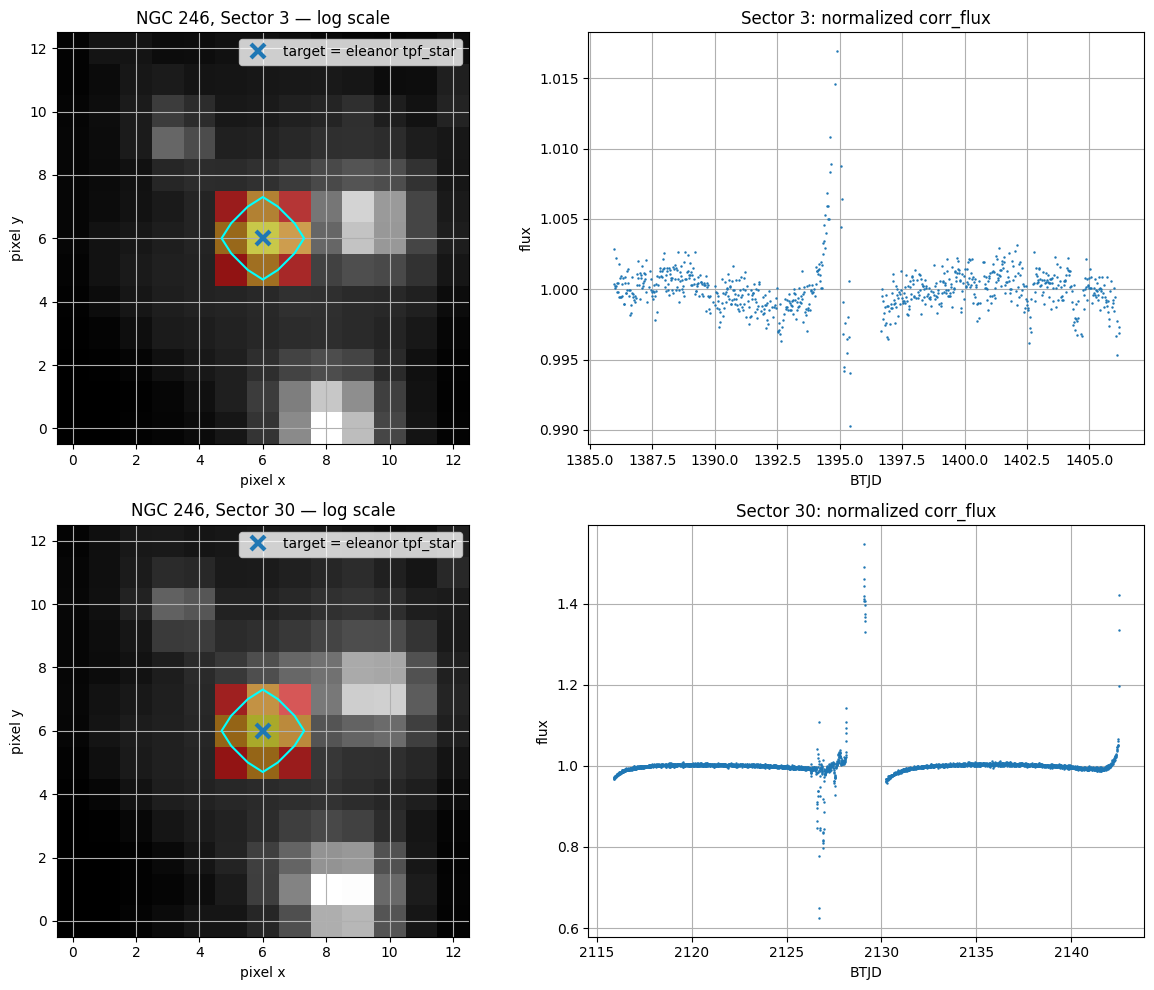

In [30]:
if ngc_objects:
    fig, axes = plt.subplots(
        len(ngc_objects), 2,
        figsize=(12, 5 * len(ngc_objects)),
        squeeze=False
    )

    for row, (sec, d) in enumerate(ngc_objects):
        frame = np.nanmedian(np.asarray(d.tpf), axis=0)
        ap = np.asarray(d.aperture)

        target_x = getattr(d, "tpf_star_x", None)
        target_y = getattr(d, "tpf_star_y", None)

        axes[row, 0].imshow(
            frame,
            origin="lower",
            cmap="gray",
            norm=positive_log_norm(frame)
        )
        axes[row, 0].imshow(
            np.ma.masked_where(ap <= 0, ap),
            origin="lower", cmap="autumn", alpha=0.5
        )
        axes[row, 0].contour(ap, levels=[0.5], colors="cyan")

        axes[row, 0].plot(
            target_x, target_y, "x", ms=10, mew=3,
            label="target = eleanor tpf_star"
        )
        axes[row, 0].set_title(f"NGC 246, Sector {sec} — log scale")
        axes[row, 0].set_xlabel("pixel x")
        axes[row, 0].set_ylabel("pixel y")
        axes[row, 0].legend()

        q = np.asarray(d.quality) == 0
        t = np.asarray(d.time)[q]
        f = np.asarray(d.corr_flux)[q].astype(float)
        f /= np.nanmedian(f)

        axes[row, 1].plot(t, f, ".", ms=1.5)
        axes[row, 1].set_title(f"Sector {sec}: normalized corr_flux")
        axes[row, 1].set_xlabel("BTJD")
        axes[row, 1].set_ylabel("flux")

    plt.tight_layout()
    plt.show()
else:
    print("NGC 246 objects не были загружены.")


## 10.2 KELT-19: dilution от реального соседа

Главный вопрос:

> **что делает постоянный сосед с измеренной глубиной transit?**

Здесь важно различать:

- **dilution** — физическое разбавление сигнала дополнительным постоянным светом;
- **deblending** — попытка понять/разделить вклад разных источников.

Поэтому KELT-19 не доказывает, что catalog-based correction полностью отделила источники. Он показывает, почему наличие яркого соседа важно для интерпретации глубины сигнала.


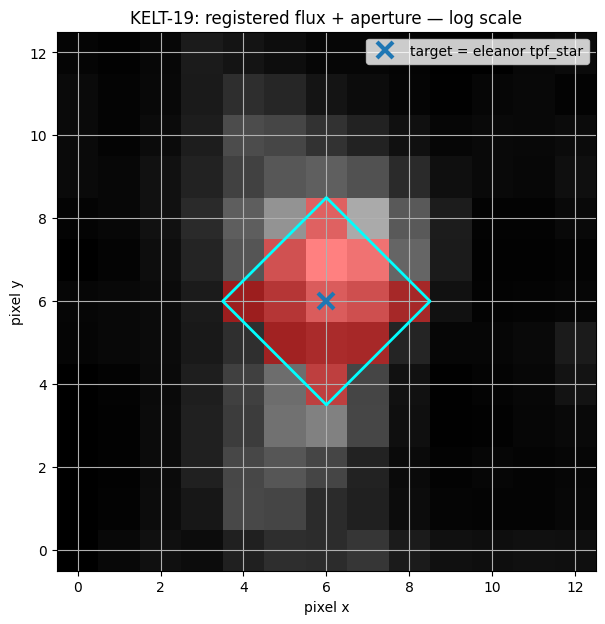

KELT-19 target position from eleanor: x=6, y=6


In [31]:
kelt_star = eleanor.Source(name="KELT-19", sector=7, tc=True)
kelt_data = eleanor.TargetData(kelt_star, do_psf=False, do_pca=False)

kelt_frame = np.nanmedian(np.asarray(kelt_data.tpf), axis=0)
kelt_ap = np.asarray(kelt_data.aperture)

kelt_target_x = getattr(kelt_data, "tpf_star_x", None)
kelt_target_y = getattr(kelt_data, "tpf_star_y", None)

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(
    kelt_frame,
    origin="lower",
    cmap="gray",
    norm=positive_log_norm(kelt_frame)
)
ax.imshow(
    np.ma.masked_where(kelt_ap <= 0, kelt_ap),
    origin="lower", cmap="autumn", alpha=0.5
)
ax.contour(kelt_ap, levels=[0.5], colors="cyan", linewidths=2)

ax.plot(
    kelt_target_x, kelt_target_y, "x", ms=11, mew=3,
    label="target = eleanor tpf_star"
)

ax.set_title("KELT-19: registered flux + aperture — log scale")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.legend()
plt.show()

print(f"KELT-19 target position from eleanor: x={kelt_target_x}, y={kelt_target_y}")


## 10.3 Почему catalog-based correction нельзя считать точным deblend?

Каталог даёт brightness соседа, но не говорит автоматически, какая доля его света попала именно в нашу aperture.

Для каждого источника:

$$
r_i=\frac{F_i}{F_t}=10^{-0.4(T_i-T_t)},
$$

$$
\alpha_i=\text{доля его flux, попавшая в photometry}.
$$

Тогда contamination относительно target:

$$
C=\frac{\sum_{i\ne t}\alpha_iF_i}{\alpha_tF_t}
  =\frac{\sum_{i\ne t}\alpha_i r_i}{\alpha_t}.
$$

А доля собственного target света:

$$
c=\frac{1}{1+C}.
$$

После этого для нормированной light curve:

$$
F_{target}(t)=1+\frac{F_{obs}(t)-1}{c}.
$$

Это **упрощённая dilution correction**, а не PRF deblending.

Почему? Потому что `alpha_i` должна быть надёжной оценкой spatial throughput каждого источника. В нашем демонстрационном коде она основана на упрощённой Gaussian PSF; полноценный TESS PRF/scene fit здесь не выполняется.


In [32]:
# Запрашиваем TIC именно для KELT-19.
from astropy.coordinates import SkyCoord
import astropy.units as u

kelt_coord = SkyCoord(
    ra=float(kelt_star.coords[0]) * u.deg,
    dec=float(kelt_star.coords[1]) * u.deg
)

try:
    kelt_tic = Catalogs.query_region(
        kelt_coord, radius=2*u.arcmin, catalog="Tic"
    ).to_pandas()

    cols = [c for c in ["ID", "ra", "dec", "Tmag"] if c in kelt_tic.columns]
    kelt_tic = kelt_tic[cols].copy()
    kelt_tic = kelt_tic.sort_values("Tmag")

    print("Каталоговые источники вокруг KELT-19:")
    display(kelt_tic.head(20))
except Exception as e:
    print("Не удалось получить TIC для KELT-19:", repr(e))
    kelt_tic = None


Каталоговые источники вокруг KELT-19:


,ID,ra,dec,Tmag
0,425206121,111.509542,7.615782,9.6540
22,425206137,111.514936,7.635589,11.9630
29,425206134,111.520775,7.635173,12.6969
26,425206099,111.517398,7.595685,13.3594
55,425206144,111.520494,7.643616,14.0374
2,425206117,111.503605,7.612267,15.1440
19,425206105,111.517271,7.598317,15.3434
14,425206116,111.495098,7.612214,15.5610
52,425206133,111.532451,7.634519,15.5666
6,425206111,111.505378,7.605841,15.7552


Три самых ярких соседа KELT-19:


,ID,ra,dec,Tmag,flux_ratio_to_target,alpha_in_aperture,estimated_contamination
0,425206121,111.509542,7.615782,9.6540,1.000000,1.0,1.000000
22,425206137,111.514936,7.635589,11.9630,0.119234,1.0,0.119234
29,425206134,111.520775,7.635173,12.6969,0.060651,1.0,0.060651


Три самых ярких TIC-соседа:


,ID,ra,dec,Tmag,flux_ratio_to_target,alpha_in_aperture,estimated_contamination
0,425206121,111.509542,7.615782,9.6540,1.000000,1.0,1.000000
22,425206137,111.514936,7.635589,11.9630,0.119234,1.0,0.119234
29,425206134,111.520775,7.635173,12.6969,0.060651,1.0,0.060651


Их pixel-положение на TPF здесь не рисуем: WCS-to-TPF mapping для этого notebook недостаточно надёжен.
Поэтому spatial-картинка ниже показывает только TPF, aperture и target position from eleanor.


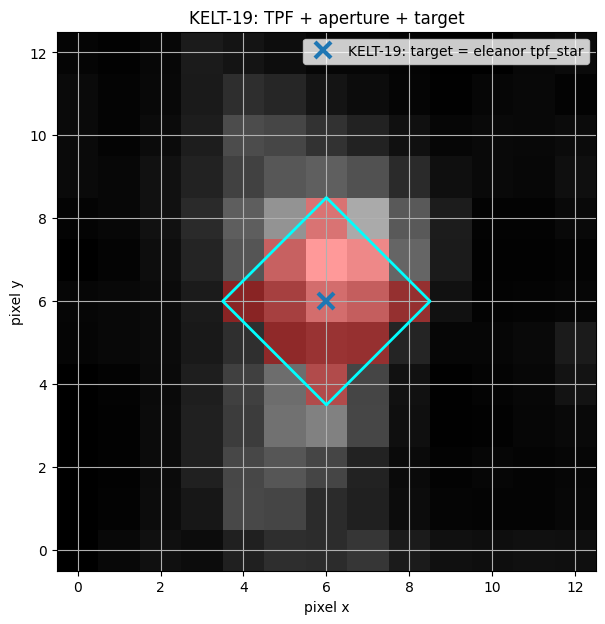

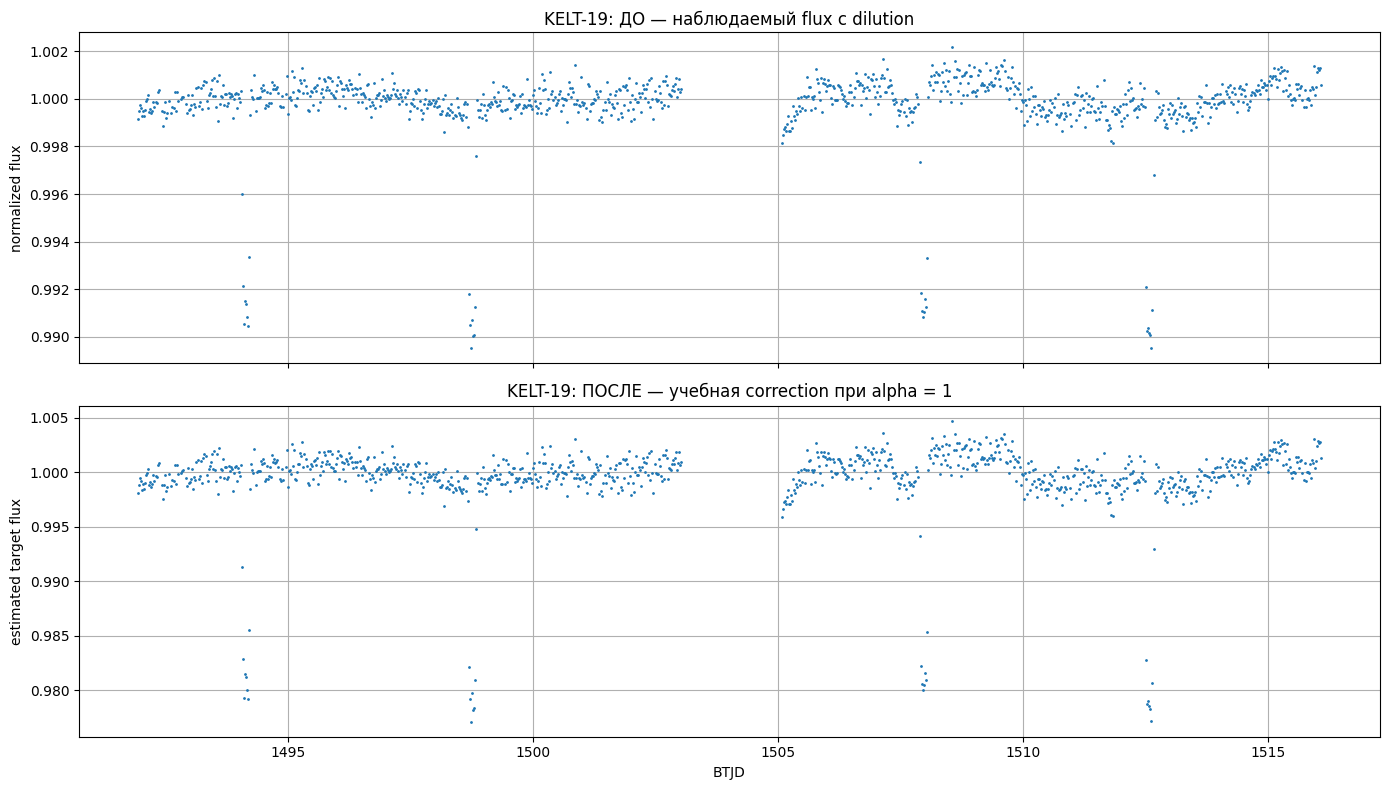

Суммарный Fcont/Ftarget в верхней оценке: 1.180
Это не точный deblend: результат зависит от неизвестных alpha/throughput.


In [33]:
# Автоматически выбираем три самых ярких TIC-соседа, исключая сам target.
# Это screening / upper-bound demonstration: alpha=1 означает,
# что временно предполагаем, что весь flux соседа попал в photometry.

if kelt_tic is not None and len(kelt_tic) > 0:
    target_id = int(kelt_star.tic)
    neighbors = (
        kelt_tic[kelt_tic["ID"] != target_id]
        .dropna(subset=["Tmag"])
        .sort_values("Tmag")
        .head(3)
    )

    target_tmag = float(kelt_star.tess_mag)

    if len(neighbors) == 0:
        print("Соседи не найдены.")
    else:
        selected = neighbors.copy()
        selected["flux_ratio_to_target"] = 10**(
            -0.4 * (selected["Tmag"] - target_tmag)
        )
        selected["alpha_in_aperture"] = 1.0
        selected["estimated_contamination"] = (
            selected["flux_ratio_to_target"] * selected["alpha_in_aperture"]
        )
        Fcont = float(selected["estimated_contamination"].sum())

        print("Три самых ярких соседа KELT-19:")
        display(selected)

        print("Три самых ярких TIC-соседа:")
        display(selected)

        print(
            "Их pixel-положение на TPF здесь не рисуем: WCS-to-TPF mapping "
            "для этого notebook недостаточно надёжен."
        )
        print(
            "Поэтому spatial-картинка ниже показывает только TPF, aperture "
            "и target position from eleanor."
        )

        fig, ax = plt.subplots(figsize=(8, 7))
        ax.imshow(kelt_frame, origin="lower", cmap="gray", norm=positive_log_norm(kelt_frame))
        ax.imshow(
            np.ma.masked_where(kelt_ap <= 0, kelt_ap),
            origin="lower", cmap="autumn", alpha=0.4
        )
        ax.contour(kelt_ap, levels=[0.5], colors="cyan", linewidths=2)
        ax.plot(
            kelt_target_x, kelt_target_y, "x", ms=11, mew=3,
            label="KELT-19: target = eleanor tpf_star"
        )
        ax.set_title("KELT-19: TPF + aperture + target")
        ax.set_xlabel("pixel x")
        ax.set_ylabel("pixel y")
        ax.legend(loc="best")
        plt.show()

        qk = np.asarray(kelt_data.quality) == 0
        tk = np.asarray(kelt_data.time)[qk].astype(float)
        fk = np.asarray(kelt_data.corr_flux)[qk].astype(float)
        fk = fk / np.nanmedian(fk)
        target_est = fk * (1 + Fcont) - Fcont

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        axes[0].plot(tk, fk, ".", ms=2)
        axes[0].set_ylabel("normalized flux")
        axes[0].set_title("KELT-19: ДО — наблюдаемый flux с dilution")

        axes[1].plot(tk, target_est, ".", ms=2)
        axes[1].set_ylabel("estimated target flux")
        axes[1].set_xlabel("BTJD")
        axes[1].set_title("KELT-19: ПОСЛЕ — учебная correction при alpha = 1")

        plt.tight_layout()
        plt.show()

        print(f"Суммарный Fcont/Ftarget в верхней оценке: {Fcont:.3f}")
        print("Это не точный deblend: результат зависит от неизвестных alpha/throughput.")
else:
    print("Не удалось получить TIC для KELT-19.")


# 11. Что мы теперь умеем делать?

Мы прошли путь от простой картинки TPF до spatial diagnostics.

| Вопрос | Метод | Что получаем | Главное ограничение |
|---|---|---|---|
| Где находится поток? | TPF / median TPF | spatial structure | не показывает сам по себе, кто переменный |
| Где находится target в текущем notebook? | `eleanor.tpf_star_x/y` | рабочую координату target | это не независимый astrometric fit |
| Как получить light curve? | aperture photometry | сумму flux выбранных pixels | источники внутри aperture смешиваются |
| Как влияет размер aperture? | fixed-center experiment | target flux / contamination trade-off | не даёт точного deblend |
| Кто находится рядом? | TIC / Gaia | candidate contaminators | каталог не даёт точную aperture throughput |
| Есть ли известная переменность? | Gaia variability | дополнительный риск | отсутствие classification не доказывает постоянство |
| Где произошло изменение? | difference image | spatial localization | чувствительно к IE/OOE и alignment |
| Где центр изменения? | flux-weighted centroid | координату переменного flux | не разделяет источники |
| Нужна ли модель? | Gaussian / scene modeling / TGLC | дополнительная проверка | model-dependent assumptions |

### Главная мысль

Ни один из этих методов не является «deblending button».

Они отвечают на разные вопросы:

**aperture → как измерить flux**

**catalog screening → кто может загрязнять**

**dilution → насколько может измениться измеренная глубина**

**difference imaging → где произошло изменение**

**centroid → где находится центр изменившегося flux**

**scene modeling → как попытаться разделить несколько источников количественно**


# 12. Как эту логику переносить в будущий ML-pipeline?

Для большого каталога разумно идти от дешёвых и устойчивых diagnostics к более сложным:

1. получить target coordinates из TIC/Gaia;
2. получить TPF;
3. проверить target position через `eleanor.tpf_star_x/y`;
4. для каталожных sources выполнить Gaia proper-motion propagation к эпохе TESS;
5. перевести Gaia/TIC coordinates в TPF через проверенный WCS mapping;
6. визуализировать TPF в log scale;
7. получить TIC/Gaia crowding features и выделить candidate contaminators;
8. оценить `alpha_i`, `C` и `c` — с явной пометкой model-dependent assumptions;
9. проверить известных variable neighbors;
10. получить light curve и отдельно контролировать detrending/PCA;
11. для подозрительных событий построить difference image;
12. вычислить event centroid;
13. сравнить event position с target и каталоговыми positions;
14. только для сложных случаев применять PRF/scene modeling или внешний cross-check;
15. сохранять diagnostics, uncertainty и quality flags как признаки для ML.

### Принцип

**Сначала максимально простая диагностика с минимальным количеством предположений → затем более сложная модель только там, где она действительно нужна.**

Это позволяет отдельно контролировать:

- photometric extraction;
- crowding/dilution;
- spatial localization;
- detrending;
- качество исходных данных для ML.


## Источники для обсуждения

- Feinstein et al. (2019), **eleanor: An Open-source Tool for Extracting Light Curves from TESS Full-frame Images** — `TargetData`, apertures, centroid и detrending.
- Kostov et al. (2024), **101 eclipsing quadruple star candidates discovered in TESS full frame images** — TIC 244279814, два набора затмений, pixel-by-pixel vetting.
- NASA TESS / HEASARC, **Understanding Crowding** — смысл CROWDSAP и FLFRCSAP.
- Gaia DR3 documentation — astrometry, proper motion и variability classifications.

### Что важно помнить о координатах

В этом notebook WCS-to-TPF mapping **используется** для каталожных источников.

Схема:

**Gaia position at 2016.0 → proper-motion propagation → TESS epoch → `WCS.all_world2pix(..., origin=0)` → swap axes → offset 31×31 → 15×15 TPF.**

Она соответствует описанной в `wcs_gaia.txt` схеме WCS и исправляет прежнее ограничение notebook, где WCS сознательно не использовался.

### Что здесь не делаем

PSF/PRF не используются как основной «deblending button». Они появляются только для демонстрации того, как из catalog magnitude и spatial throughput получить модельные `C` и `c`.

Поэтому результаты каталожной contamination оценки нужно маркировать как **model-dependent diagnostic**, а не как точное разделение flux.
